# 📓 Emotion Detection from Text
## An NLP Performance and Explainability Audit

**Course:** Natural Language Processing — CA3: Build–Audit–Pitch Mini NLP Project
**Dataset:** `dair-ai/emotion` (Hugging Face), configuration `split`
**Approach:** TF-IDF text representation + Logistic Regression classifier, followed by a subgroup performance audit and a coefficient-based explainability analysis

---

### 📑 Notebook Contents

| # | Section | Rubric component |
|---|---|---|
| 1 | Project Definition | Build – problem description |
| ⚙️ | Environment Setup & Reproducibility | Build – reproducibility |
| 2 | Dataset Loading | Build – real dataset |
| 3 | Dataset Understanding | Build – dataset description |
| 4 | Exploratory Data Analysis | Build – dataset description |
| 5 | Data Quality Check | Build – dataset description |
| 6 | Text Preprocessing | Build – preprocessing |
| 7 | Train / Validation / Test Preparation (incl. leakage prevention) | Build – approach |
| 8 | Text Representation | Build – approach |
| 9 | NLP Model Development | Build – approach/model |
| 10 | Model Training | Build – approach/model |
| 11 | Model Evaluation | Build – results |
| 12 | Error Analysis | Build – results |
| 13 | Performance / Bias Audit (two text subgroups/styles) | Audit |
| 14 | Explainability Analysis | Audit |
| 15 | Model Limitations | Audit |
| 16 | New Text Prediction Demo | Pitch – live demo |




# 1. Project Definition

### Project title
**Emotion Detection from Text: An NLP Performance and Explainability Audit**

### Problem statement
People express emotions in short written messages (posts, tweets, reviews, chats). Reading thousands of such messages by hand is slow. We want a system that reads a short English sentence and automatically identifies the **main emotion** expressed in it. Because such a system could be used to make decisions about people, we must also check **where it works well, where it fails, and why it makes its predictions**, not only its overall accuracy.

### Objective
1. Build a complete, working NLP pipeline that classifies a sentence into one of the emotion classes present in the dataset.
2. Evaluate it with metrics that go beyond accuracy (precision, recall, F1, confusion matrix).
3. **Audit** the model's performance across **two measurable text subgroups/styles**.
4. **Explain** the model's predictions with a simple explainability method.
5. Honestly document the model's **limitations** and summarise everything in a **model card**.

### NLP task
**Single-label, multi-class text classification** (emotion classification). The exact set of emotion classes is read from the dataset in Section 3, not assumed.

| Item | Description |
|---|---|
| **Input** | One short English text (a sentence / social-media message) |
| **Output** | One predicted emotion label + a probability (confidence) for each emotion |
| **Learning type** | Supervised learning (labelled examples) |

### Why is emotion detection an NLP problem?
- The input is **unstructured natural language**. A computer cannot use raw sentences directly, so the text must be converted into numbers (a *representation*).
- Emotion is carried by **words and word combinations** (e.g. *"terrified"*, *"not happy"*), so the model must learn which linguistic patterns signal which emotion.
- Language is **ambiguous**: the same word can signal different emotions depending on context, negation or sarcasm. This is exactly what makes the audit and explainability parts important.

### Project scope
- **In scope:** English short texts from the chosen dataset; the emotion classes defined by the dataset; a classical, explainable NLP pipeline; subgroup audit; explainability; limitations.
- **Out of scope:** multi-label emotions, emotion *intensity*, other languages, speech/audio, and deployment for real decisions about people.

### Overall pipeline
```
 Raw Text
    ↓
 Preprocessing            (clean & normalise the text)
    ↓
 Text Representation      (TF-IDF: text → numbers)
    ↓
 NLP Model                (Logistic Regression)
    ↓
 Emotion Prediction       (label + probability)
    ↓
 Evaluation               (accuracy, precision, recall, F1, confusion matrix)
    ↓
 Audit                    (performance across two text subgroups/styles)
    ↓
 Explainability           (which words drove the prediction?)
```



# ⚙️ Environment Setup & Reproducibility



In [4]:
# ---- Install required packages only if missing (Colab usually has them) ----
import importlib, subprocess, sys

def ensure_package(pip_name, import_name=None, required=True):
    # Import a package; install it quietly with pip if it is missing.
    try:
        importlib.import_module(import_name or pip_name)
        return True
    except ImportError:
        print(f"Installing {pip_name} ...")
        for extra in ([], ["--break-system-packages"]):   # 2nd attempt only needed on some non-Colab systems
            if subprocess.call([sys.executable, "-m", "pip", "install", "-q", pip_name, *extra]) == 0:
                importlib.invalidate_caches()
                return True
        msg = f"Could not install '{pip_name}'."
        if required:
            raise RuntimeError(msg + " Please install it manually and re-run.")
        print("⚠️ " + msg + " Continuing (the dataset loader has a fallback).")
        return False

for pkg in ["scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"]:
    ensure_package(pkg, {"scikit-learn": "sklearn"}.get(pkg))
ensure_package("datasets", required=False)   # needed for Hugging Face loading
print("Package check complete.")

Package check complete.


In [5]:
# ---- Imports ----
import os, re, random, warnings, platform
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score,
                             classification_report, confusion_matrix)
from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# ---- Reproducibility ----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ---- Plot style (clean, readable, colour-blind friendly) ----
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.width", 200)

print(f"Python       : {platform.python_version()}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"matplotlib   : {plt.matplotlib.__version__}")
print(f"seaborn      : {sns.__version__}")
print(f"Random seed  : {SEED}")

Python       : 3.13.16
numpy        : 2.1.3
pandas       : 2.2.3
scikit-learn : 1.6.1
matplotlib   : 3.10.0
seaborn      : 0.13.2
Random seed  : 42


# 2. Dataset Loading

**Source:** Hugging Face dataset [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion).

The dataset offers two configurations:

| Configuration | What it contains | Used here? |
|---|---|---|
| `split` | The dataset with **official train / validation / test splits** | ✅ **Yes** |
| `unsplit` | A much larger single table with **no** official splits | ❌ No |



In [6]:
DATASET_NAME   = "dair-ai/emotion"
DATASET_CONFIG = "split"
REQUIRED_SPLITS = ["train", "validation", "test"]

# Fallback: public GitHub copy of the same 'split' data (text;label per line).
# Used ONLY if the Hugging Face Hub cannot be reached.
FALLBACK_URLS = {
    "train":      "https://raw.githubusercontent.com/nimit-singh/Kaggle-Emotions-Dataset-for-NLP/main/Data/train.txt",
    "validation": "https://raw.githubusercontent.com/nimit-singh/Kaggle-Emotions-Dataset-for-NLP/main/Data/val.txt",
    "test":       "https://raw.githubusercontent.com/nimit-singh/Kaggle-Emotions-Dataset-for-NLP/main/Data/test.txt",
}
# Label order as documented on the Hugging Face dataset card (id -> name). Used ONLY by the fallback,
# because the fallback files store label *names* instead of ids. It is validated against the files below.
FALLBACK_LABEL_ORDER = ["sadness", "joy", "love", "anger", "fear", "surprise"]


def load_from_huggingface():
    from datasets import load_dataset
    ds = load_dataset(DATASET_NAME, DATASET_CONFIG)
    missing = [s for s in REQUIRED_SPLITS if s not in ds]
    if missing:
        raise ValueError(f"Expected splits {REQUIRED_SPLITS}, but these are missing: {missing}. Found: {list(ds.keys())}")
    frames = {s: ds[s].to_pandas() for s in REQUIRED_SPLITS}
    # Detect the text and label columns from the dataset schema instead of assuming them
    feats = ds["train"].features
    label_cols = [c for c, f in feats.items() if f.__class__.__name__ == "ClassLabel"]
    if len(label_cols) != 1:
        raise ValueError(f"Could not identify a single ClassLabel column. Features: {feats}")
    label_col = label_cols[0]
    text_cols = [c for c, f in feats.items() if getattr(f, "dtype", None) == "string"]
    if len(text_cols) != 1:
        raise ValueError(f"Could not identify a single text column. Features: {feats}")
    label_names = list(feats[label_col].names)
    return frames, text_cols[0], label_col, label_names, f"Hugging Face Hub ({DATASET_NAME}, config='{DATASET_CONFIG}')"


def load_from_fallback():
    frames = {}
    for s, url in FALLBACK_URLS.items():
        df = pd.read_csv(url, sep=";", header=None, names=["text", "label_name"], quoting=3)
        unknown = set(df["label_name"]) - set(FALLBACK_LABEL_ORDER)
        if unknown:
            raise ValueError(f"Fallback file for '{s}' contains unknown labels: {unknown}")
        df["label"] = df["label_name"].map({n: i for i, n in enumerate(FALLBACK_LABEL_ORDER)})
        frames[s] = df[["text", "label"]]
    return frames, "text", "label", list(FALLBACK_LABEL_ORDER), "GitHub mirror of dair-ai/emotion 'split' (fallback)"


try:
    raw_splits, TEXT_COL, LABEL_COL, LABEL_NAMES, DATA_SOURCE = load_from_huggingface()
except Exception as e:
    print(f"⚠️ Hugging Face loading failed ({type(e).__name__}: {str(e)[:150]}).")
    print("   Falling back to the GitHub copy of the same data ...")
    raw_splits, TEXT_COL, LABEL_COL, LABEL_NAMES, DATA_SOURCE = load_from_fallback()

print(f"✅ Data source      : {DATA_SOURCE}")
print(f"   Text column      : '{TEXT_COL}'")
print(f"   Label column     : '{LABEL_COL}'")
print(f"   Label names      : {LABEL_NAMES}")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Data source      : Hugging Face Hub (dair-ai/emotion, config='split')
   Text column      : 'text'
   Label column     : 'label'
   Label names      : ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


### 2.1 Automatic validation checks
Before using the data, we verify that it is what we expect. If a check fails, the notebook stops with a clear message instead of silently producing wrong results.

In [7]:
def validate_split(name, df):
    assert TEXT_COL in df.columns,  f"[{name}] text column '{TEXT_COL}' not found. Columns: {list(df.columns)}"
    assert LABEL_COL in df.columns, f"[{name}] label column '{LABEL_COL}' not found. Columns: {list(df.columns)}"
    assert len(df) > 0, f"[{name}] split is empty"
    assert df[LABEL_COL].notna().all(), f"[{name}] contains missing labels"
    valid_ids = set(range(len(LABEL_NAMES)))
    bad = set(df[LABEL_COL].unique()) - valid_ids
    assert not bad, f"[{name}] contains invalid label ids: {bad}"

for split_name in REQUIRED_SPLITS:
    validate_split(split_name, raw_splits[split_name])

NUM_CLASSES = len(LABEL_NAMES)
ID2LABEL = dict(enumerate(LABEL_NAMES))

# Build clean working copies with a readable 'emotion' column (decoded from the dataset's own label mapping)
data = {}
for s in REQUIRED_SPLITS:
    df = raw_splits[s][[TEXT_COL, LABEL_COL]].rename(columns={TEXT_COL: "text", LABEL_COL: "label"}).copy()
    df["label"] = df["label"].astype(int)
    df["emotion"] = df["label"].map(ID2LABEL)
    df["split"] = s
    data[s] = df.reset_index(drop=True)

print("All validation checks passed ✅")
print(pd.DataFrame({"split": REQUIRED_SPLITS,
                    "rows": [len(data[s]) for s in REQUIRED_SPLITS],
                    "columns": [list(raw_splits[s].columns) for s in REQUIRED_SPLITS]}).to_string(index=False))

All validation checks passed ✅
     split  rows       columns
     train 16000 [text, label]
validation  2000 [text, label]
      test  2000 [text, label]


# 3. Dataset Understanding

Here we inspect the structure of the dataset automatically: rows, columns, data types, which column is the input and which is the target, the label mapping, and how many examples each class has.

In [8]:
full = pd.concat([data[s] for s in REQUIRED_SPLITS], ignore_index=True)

print("=== Basic structure (original dataset columns) ===")
print(f"Total rows (all splits)     : {len(full):,}")
print(f"Original columns            : {list(raw_splits['train'].columns)}")
print(f"Number of original columns  : {raw_splits['train'].shape[1]}")
print(f"Input / text column         : '{TEXT_COL}'  -> renamed 'text'")
print(f"Target / label column       : '{LABEL_COL}' -> kept as 'label' (id) + decoded 'emotion' (name)")
print(f"Number of classes           : {NUM_CLASSES}")
print()
print("=== Data types (working copy) ===")
print(data["train"].dtypes.to_string())

=== Basic structure (original dataset columns) ===
Total rows (all splits)     : 20,000
Original columns            : ['text', 'label']
Number of original columns  : 2
Input / text column         : 'text'  -> renamed 'text'
Target / label column       : 'label' -> kept as 'label' (id) + decoded 'emotion' (name)
Number of classes           : 6

=== Data types (working copy) ===
text       object
label       int64
emotion    object
split      object


In [9]:
print("=== Label mapping (read from the dataset) ===")
display(pd.DataFrame({"label_id": list(ID2LABEL.keys()), "emotion": list(ID2LABEL.values())}))

print("=== Examples per class in each split ===")
class_counts = (full.groupby(["emotion", "split"]).size().unstack("split")[REQUIRED_SPLITS]
                .reindex(LABEL_NAMES))
class_counts.loc["TOTAL"] = class_counts.sum()
display(class_counts)

=== Label mapping (read from the dataset) ===


,label_id,emotion
0,0,sadness
1,1,joy
2,2,love
3,3,anger
4,4,fear
5,5,surprise


=== Examples per class in each split ===


split,train,validation,test
emotion,,,
sadness,4666,550,581
joy,5362,704,695
love,1304,178,159
anger,2159,275,275
fear,1937,212,224
surprise,572,81,66
TOTAL,16000,2000,2000


In [10]:
print("=== Representative examples (random, reproducible) ===")
display(data["train"].sample(8, random_state=SEED)[["text", "label", "emotion"]])

=== Representative examples (random, reproducible) ===


,text,label,emotion
8756,ive made it through a week i just feel beaten down,0,sadness
4660,i feel this strategy is worthwhile,1,joy
6095,i feel so worthless and weak what does he have to say that s what i want to find out,0,sadness
304,i feel clever nov,1,joy
8241,im moved in ive been feeling kind of gloomy,0,sadness
9577,i allowed myself to feel the really shitty feelings while i was running because a the endorphins were flowing so it hurt less and b so i could pretend i was...,0,sadness
1035,i feel confused too,4,fear
9976,i feel like a crappy mummy if were stuck in but there are days where i really cant face much else then venturing out to the garden at pm,0,sadness


# 4. Exploratory Data Analysis (EDA)

Each plot below answers a specific question about the data. After each plot there is an **auto-generated summary** (numbers computed by code) and a short interpretation.

We run EDA mainly on the **training set**, because in a real project the training data is what we are allowed to study. Test-set details are only used for evaluation later. Where we compare splits, we use only counts.

In [11]:
EMOTION_COLORS = dict(zip(LABEL_NAMES, sns.color_palette("colorblind", NUM_CLASSES)))

# Length features (used throughout EDA and later in the audit)
for s in REQUIRED_SPLITS:
    data[s]["char_count"] = data[s]["text"].str.len()
    data[s]["word_count"] = data[s]["text"].str.split().str.len()
train_df = data["train"]

### 4.A Dataset size per split


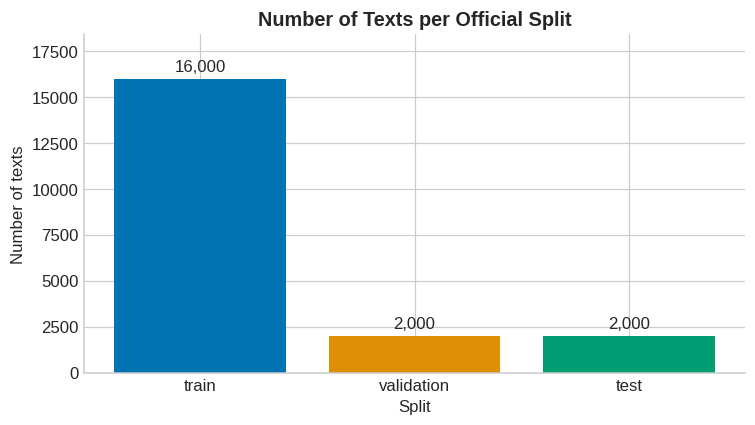

**Auto-summary:** train = 16,000 (80.0%), validation = 2,000 (10.0%), test = 2,000 (10.0%).

In [12]:
sizes = pd.Series({s: len(data[s]) for s in REQUIRED_SPLITS})
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(sizes.index, sizes.values, color=sns.color_palette("colorblind", 3))
ax.bar_label(bars, labels=[f"{v:,}" for v in sizes.values], padding=3)
ax.set_title("Number of Texts per Official Split")
ax.set_xlabel("Split"); ax.set_ylabel("Number of texts")
ax.set_ylim(0, sizes.max() * 1.15)
plt.tight_layout(); plt.show()

share = (sizes / sizes.sum() * 100).round(1)
display(Markdown(f"**Auto-summary:** train = {sizes['train']:,} ({share['train']}%), "
                 f"validation = {sizes['validation']:,} ({share['validation']}%), test = {sizes['test']:,} ({share['test']}%)."))

**Interpretation:** Most of the data is in the training split, with smaller validation and test splits of equal size. The test set is large enough to give stable overall metrics, but some small classes will have few test examples. We keep this in mind when reading per-class and subgroup results.

### 4.B–C Class (emotion) distribution: counts and percentages


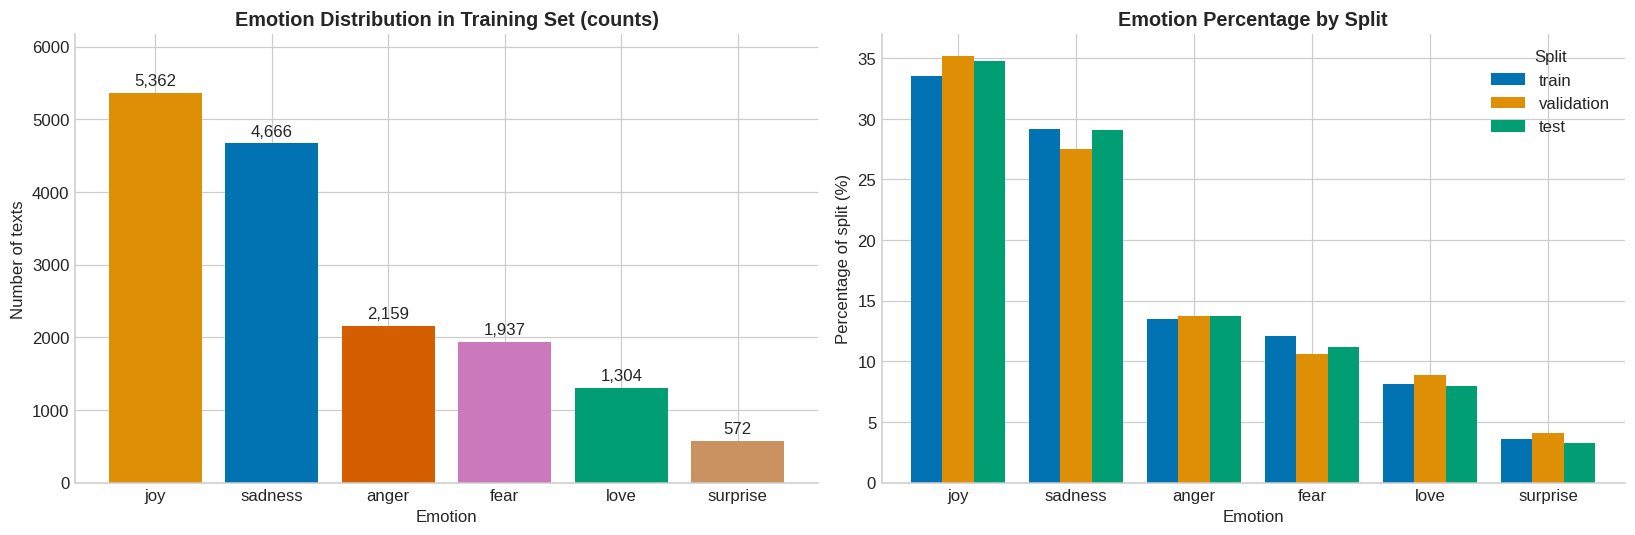

,train,validation,test
emotion,,,
joy,33.51,35.20,34.75
sadness,29.16,27.50,29.05
anger,13.49,13.75,13.75
fear,12.11,10.60,11.20
love,8.15,8.90,7.95
surprise,3.58,4.05,3.30


**Auto-summary:** Largest class = **joy** (5,362 texts, 33.5%); smallest class = **surprise** (572 texts, 3.6%). Imbalance ratio (largest/smallest) = **9.4×**. Maximum difference in a class's percentage between splits = **1.69 percentage points**.

In [13]:
counts = train_df["emotion"].value_counts().reindex(LABEL_NAMES)
order = counts.sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# (B) counts in training set
b = axes[0].bar(order, counts[order].values, color=[EMOTION_COLORS[e] for e in order])
axes[0].bar_label(b, labels=[f"{v:,}" for v in counts[order].values], padding=3)
axes[0].set_title("Emotion Distribution in Training Set (counts)")
axes[0].set_xlabel("Emotion"); axes[0].set_ylabel("Number of texts")
axes[0].set_ylim(0, counts.max() * 1.15)

# (C) percentage per split
pct = (full.groupby("split")["emotion"].value_counts(normalize=True).mul(100)
       .unstack("emotion")[order].loc[REQUIRED_SPLITS])
pct.T.plot(kind="bar", ax=axes[1], color=sns.color_palette("colorblind", 3), width=0.8)
axes[1].set_title("Emotion Percentage by Split")
axes[1].set_xlabel("Emotion"); axes[1].set_ylabel("Percentage of split (%)")
axes[1].tick_params(axis="x", rotation=0); axes[1].legend(title="Split")
plt.tight_layout(); plt.show()

pct_table = pct.T.round(2); pct_table.columns.name = None
display(pct_table)
imbalance_ratio = counts.max() / counts.min()
display(Markdown(
    f"**Auto-summary:** Largest class = **{counts.idxmax()}** ({counts.max():,} texts, {counts.max()/counts.sum()*100:.1f}%); "
    f"smallest class = **{counts.idxmin()}** ({counts.min():,} texts, {counts.min()/counts.sum()*100:.1f}%). "
    f"Imbalance ratio (largest/smallest) = **{imbalance_ratio:.1f}×**. "
    f"Maximum difference in a class's percentage between splits = **{(pct.max() - pct.min()).max():.2f} percentage points**."))

**Interpretation:** The dataset is clearly **imbalanced**. A few emotions dominate and at least one class is much rarer. The class percentages are very similar across the three splits, so the official splits are consistent with each other.



### 4.D–E Text length: characters and words


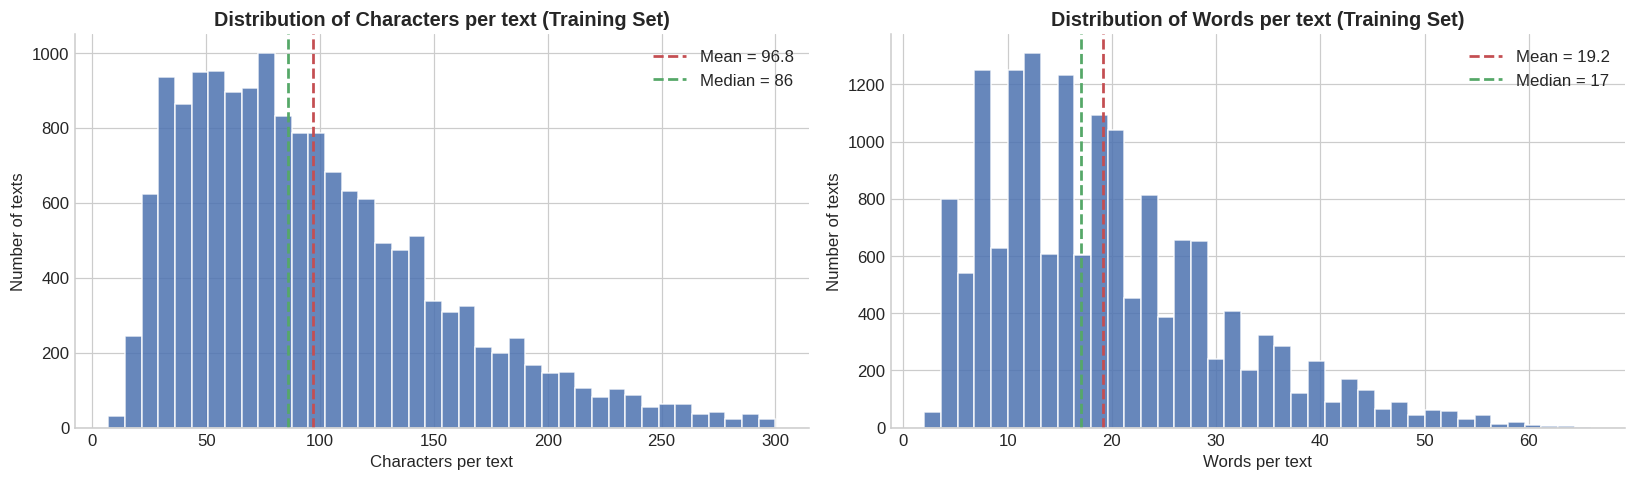

,count,mean,std,min,25%,50%,75%,max
char_count,16000.0,96.8,55.9,7.0,53.0,86.0,129.0,300.0
word_count,16000.0,19.2,11.0,2.0,11.0,17.0,25.0,66.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
for ax, col, label in [(axes[0], "char_count", "Characters per text"), (axes[1], "word_count", "Words per text")]:
    ax.hist(train_df[col], bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(train_df[col].mean(), color="#C44E52", ls="--", lw=1.8, label=f"Mean = {train_df[col].mean():.1f}")
    ax.axvline(train_df[col].median(), color="#55A868", ls="--", lw=1.8, label=f"Median = {train_df[col].median():.0f}")
    ax.set_title(f"Distribution of {label} (Training Set)")
    ax.set_xlabel(label); ax.set_ylabel("Number of texts"); ax.legend()
plt.tight_layout(); plt.show()

length_stats = train_df[["char_count", "word_count"]].describe().T.round(1)
display(length_stats)

**Interpretation:** The texts are **short** (sentence-length), and the distribution is **right-skewed**: most texts are short, with a tail of longer ones. Short texts give the model limited context, while long texts may mix several feelings. Text length is therefore a natural, measurable **audit dimension** (Section 13).

### 4.F Text length by emotion


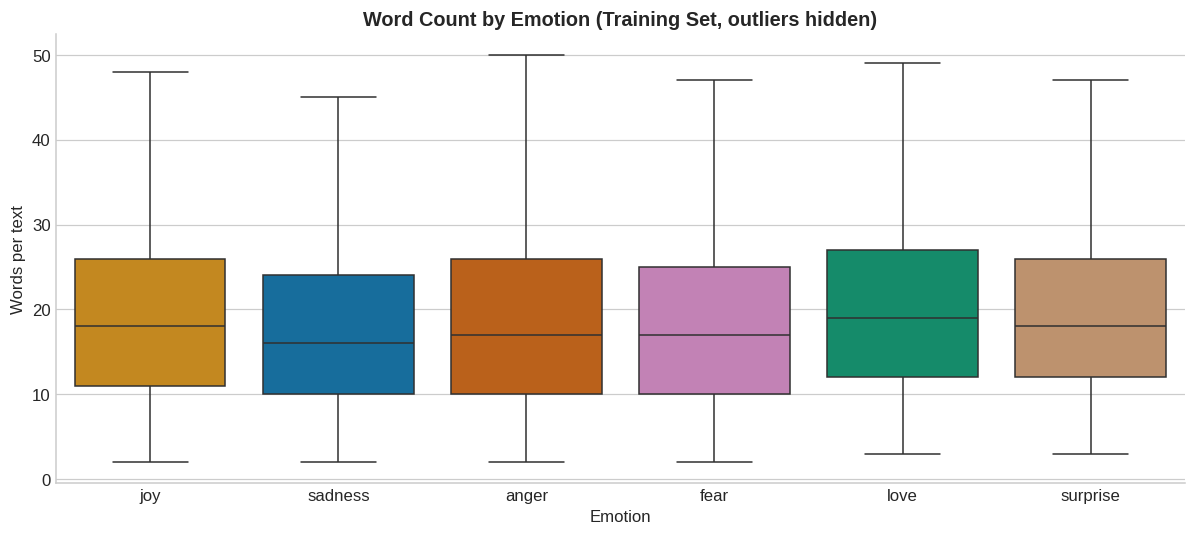

,mean,median,min,max
emotion,,,,
joy,19.5,18.0,2,64
sadness,18.4,16.0,2,66
anger,19.2,17.0,2,62
fear,18.8,17.0,2,60
love,20.7,19.0,3,63
surprise,20.0,18.0,3,60


**Auto-summary:** Median word count ranges from **16** (*sadness*) to **19** (*love*).

In [15]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=train_df, x="emotion", y="word_count", order=order, hue="emotion", legend=False,
            palette=EMOTION_COLORS, ax=ax, showfliers=False)
ax.set_title("Word Count by Emotion (Training Set, outliers hidden)")
ax.set_xlabel("Emotion"); ax.set_ylabel("Words per text")
plt.tight_layout(); plt.show()

by_emo = train_df.groupby("emotion")["word_count"].agg(["mean", "median", "min", "max"]).reindex(order).round(1)
display(by_emo)
display(Markdown(f"**Auto-summary:** Median word count ranges from **{by_emo['median'].min():.0f}** "
                 f"(*{by_emo['median'].idxmin()}*) to **{by_emo['median'].max():.0f}** (*{by_emo['median'].idxmax()}*)."))

**Interpretation:** Length distributions overlap strongly across emotions. Length alone cannot identify the emotion, so the model has to rely on the **words** themselves. The small differences between classes also mean that a length-based subgroup will contain a slightly different emotion mix. We check this possible *confounder* in the audit.

### 4.G Representative examples from each emotion

In [16]:
examples = train_df.groupby("emotion").sample(3, random_state=SEED)[["emotion", "text"]].copy()
examples["emotion"] = pd.Categorical(examples["emotion"], categories=order, ordered=True)
display(examples.sort_values("emotion").reset_index(drop=True))

,emotion,text
0,joy,i want you on the trip that i feel is cool
1,joy,i do not feel glamourous
2,joy,i want to be in the future years some of you made me feel amazing and some of you are the best friends i could ever ask for
3,sadness,i feel a little less burdened
4,sadness,im not sure why today i feel so horrible
5,sadness,i feel so disappointed
6,anger,i ve been feeling a bit cranky with the kids this week cranky baby whiny year old demanding preschooler so i wanted to stop and remember how blessed i reall...
7,anger,i feeling stressed
8,anger,i feel frustrated sometimes with my mac lipsticks when i have to read names or open each of them to select shade
9,fear,i have to admit i feel a little hesitant about embedding a music video below in this case


### 4.H–I Shortest and longest texts

In [17]:
print("=== 8 shortest training texts ===")
display(train_df.nsmallest(8, "word_count")[["text", "emotion", "word_count"]].reset_index(drop=True))
print("=== 3 longest training texts ===")
display(train_df.nlargest(3, "word_count")[["text", "emotion", "word_count"]].reset_index(drop=True))

=== 8 shortest training texts ===


,text,emotion,word_count
0,earth crake,fear,2
1,during lectures,joy,2
2,in sweden,fear,2
3,no response,anger,2
4,one night,joy,2
5,at school,anger,2
6,one day,sadness,2
7,no description,anger,2


=== 3 longest training texts ===


,text,emotion,word_count
0,i guess which meant or so i assume no photos no words or no other way to convey what it really feels unless you feels it yourself or khi bi t au th m i bi t...,sadness,66
1,i lost my special mind but don t worry i m still sane i just wanted you to feel what i felt while reading this book i don t know how many times it was said ...,joy,64
2,i am happier this year in all ways i am just glad i am on english lit only i made good module choices i like my teachers the peeps in my class are not so sn...,joy,64


**Interpretation:** Some of the shortest texts (only two or three words) contain **no obvious emotional word at all**, yet they still carry an emotion label. For such texts the label cannot really be inferred from the text alone, which sets a natural ceiling on performance. The longest texts often describe **mixed situations** with more than one feeling.

### 4.J Additional dataset-specific EDA
Three checks that matter specifically for this dataset:
1. **Text style:** Is the text already lower-cased and punctuation-free? This decides what preprocessing is needed.
2. **The word "feel":** How often does a text contain *feel / feeling / felt*? A very high share would reveal a collection pattern (a writing style specific to this dataset).
3. **Negation:** How often do texts contain negation words (*not, never, didnt …*)? Negation can reverse an emotion, which makes it a meaningful audit dimension.

,% of all texts,count
has_uppercase,0.00,0
has_digit,0.00,0
has_punctuation,0.00,0
has_feel_word,98.78,19757
has_negation,24.24,4847
has_url_remnant,1.27,254


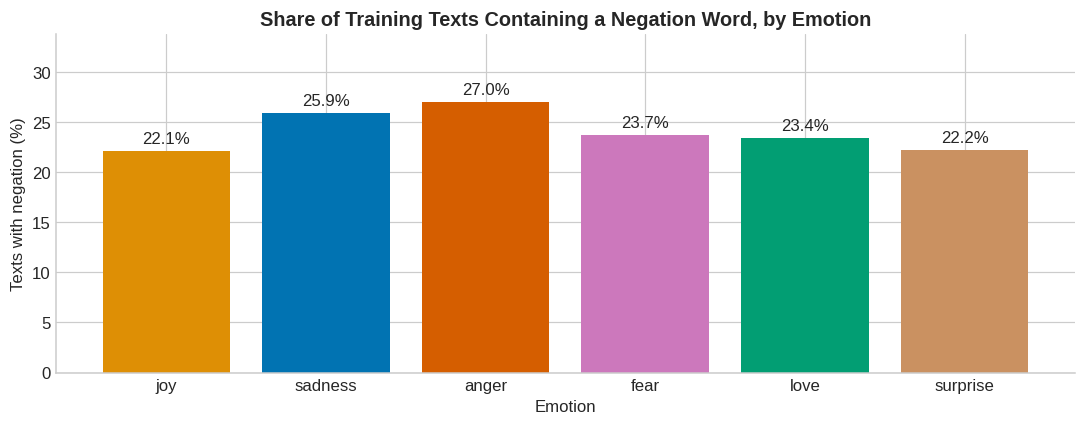

**Auto-summary:** 0.0% of texts contain uppercase letters, 0.0% contain punctuation, **98.8%** contain a form of *feel*, **24.2%** contain a negation word, and 254 texts contain leftover URL/HTML tokens (e.g. *href*, *http*).

In [18]:
# Negation lexicon used throughout the notebook (documented so the audit is reproducible).
# Contractions appear WITHOUT apostrophes in this dataset (e.g. "didnt"), so both forms are listed.
NEGATION_WORDS = ["not", "no", "never", "nothing", "nobody", "none", "nor", "neither", "without", "cannot",
                  "dont", "didnt", "doesnt", "cant", "wont", "isnt", "wasnt", "arent", "werent",
                  "havent", "hasnt", "hadnt", "wouldnt", "couldnt", "shouldnt", "aint"]
NEGATION_PATTERN = r"\b(?:" + "|".join(NEGATION_WORDS) + r")\b"

style = pd.DataFrame({
    "has_uppercase":    full["text"].str.contains(r"[A-Z]"),
    "has_digit":        full["text"].str.contains(r"\d"),
    "has_punctuation":  full["text"].str.contains(r"[^\w\s]"),
    "has_feel_word":    full["text"].str.contains(r"\b(?:feel|feels|feeling|feelings|felt)\b"),
    "has_negation":     full["text"].str.contains(NEGATION_PATTERN),
    "has_url_remnant":  full["text"].str.contains(r"\b(?:http|https|www|href|src|img)\b"),
})
style_summary = (style.mean() * 100).round(2).rename("% of all texts").to_frame()
style_summary["count"] = style.sum()
display(style_summary)

neg_by_emotion = (train_df.assign(neg=train_df["text"].str.contains(NEGATION_PATTERN))
                  .groupby("emotion")["neg"].mean().mul(100).reindex(order))
fig, ax = plt.subplots(figsize=(10, 4))
b = ax.bar(order, neg_by_emotion.values, color=[EMOTION_COLORS[e] for e in order])
ax.bar_label(b, labels=[f"{v:.1f}%" for v in neg_by_emotion.values], padding=3)
ax.set_title("Share of Training Texts Containing a Negation Word, by Emotion")
ax.set_xlabel("Emotion"); ax.set_ylabel("Texts with negation (%)"); ax.set_ylim(0, neg_by_emotion.max() * 1.25)
plt.tight_layout(); plt.show()

FEEL_SHARE = style["has_feel_word"].mean() * 100
NEG_SHARE = style["has_negation"].mean() * 100
display(Markdown(
    f"**Auto-summary:** {style_summary.loc['has_uppercase','% of all texts']}% of texts contain uppercase letters, "
    f"{style_summary.loc['has_punctuation','% of all texts']}% contain punctuation, "
    f"**{FEEL_SHARE:.1f}%** contain a form of *feel*, **{NEG_SHARE:.1f}%** contain a negation word, and "
    f"{style_summary.loc['has_url_remnant','count']} texts contain leftover URL/HTML tokens (e.g. *href*, *http*)."))

**Interpretation:**
- The texts are **already lower-cased and punctuation-free**: the dataset was distributed in this normalised form. We must therefore apply the **same normalisation to any new text** we predict on (Section 16), otherwise new inputs would look different from the training data.
- Almost every text contains a form of **"feel"**. This dataset has a very specific writing style ("*i feel …*"). This is a **domain limitation**: the model may not transfer to text written differently (Section 15).
- Roughly a quarter of texts contain a **negation word**, spread across all emotions. That is common enough to form a meaningful audit subgroup.
- A small number of texts contain **leftover web markup tokens** (from stripped links). These carry no emotional meaning, and preprocessing removes them.



# 5. Data Quality Check

We check for missing values, empty strings, invalid labels, unexpected data types, duplicates, texts that appear with **conflicting labels**, and **overlap between splits** (data leakage). Nothing is deleted silently. Every removal is counted, explained and shown.

In [19]:
qc_rows = []
for s in REQUIRED_SPLITS:
    df = data[s]
    txt_counts = df["text"].value_counts()
    dup_texts = txt_counts[txt_counts > 1].index
    conflicting = df[df["text"].isin(dup_texts)].groupby("text")["label"].nunique()
    qc_rows.append({
        "split": s,
        "rows": len(df),
        "missing_text": int(df["text"].isna().sum()),
        "missing_label": int(df["label"].isna().sum()),
        "empty_or_blank_text": int((df["text"].str.strip() == "").sum()),
        "non_string_text": int((~df["text"].map(lambda x: isinstance(x, str))).sum()),
        "invalid_label": int((~df["label"].isin(range(NUM_CLASSES))).sum()),
        "exact_duplicate_rows": int(df.duplicated(subset=["text", "label"]).sum()),
        "texts_repeated_same_label": int((conflicting == 1).sum()),
        "texts_with_conflicting_labels": int((conflicting > 1).sum()),
        "very_short_texts(<=2 words)": int((df["word_count"] <= 2).sum()),
    })
qc = pd.DataFrame(qc_rows).set_index("split").T
display(qc)

split,train,validation,test
rows,16000,2000,2000
missing_text,0,0,0
missing_label,0,0,0
empty_or_blank_text,0,0,0
non_string_text,0,0,0
invalid_label,0,0,0
exact_duplicate_rows,1,0,0
texts_repeated_same_label,1,0,0
texts_with_conflicting_labels,30,2,0
very_short_texts(<=2 words),8,1,0


### 5.1 Cross-split overlap (data-leakage check)
If the *same text* appears in both train and test, the test score can be inflated because the model has effectively seen the answer. We therefore check exact text overlap between every pair of splits, and whether the labels agree.

In [20]:
def overlap_report(a, b):
    common = set(data[a]["text"]) & set(data[b]["text"])
    if not common:
        return {"pair": f"{a} ∩ {b}", "shared_texts": 0, "same_label": 0, "different_label": 0}, pd.DataFrame()
    m = (data[a][data[a]["text"].isin(common)][["text", "emotion"]].drop_duplicates()
         .merge(data[b][data[b]["text"].isin(common)][["text", "emotion"]].drop_duplicates(),
                on="text", suffixes=(f"_{a}", f"_{b}")))
    same = int((m[f"emotion_{a}"] == m[f"emotion_{b}"]).sum())
    return {"pair": f"{a} ∩ {b}", "shared_texts": len(common), "same_label": same,
            "different_label": len(m) - same}, m

overlap_rows, overlap_examples = [], {}
for a, b in [("train", "validation"), ("train", "test"), ("validation", "test")]:
    row, m = overlap_report(a, b)
    overlap_rows.append(row); overlap_examples[(a, b)] = m
overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)

print("Examples of texts shared by train and test:")
display(overlap_examples[("train", "test")].head(6))

,pair,shared_texts,same_label,different_label
0,train ∩ validation,5,0,5
1,train ∩ test,11,0,11
2,validation ∩ test,3,0,3


Examples of texts shared by train and test:


,text,emotion_train,emotion_test
0,i feel like some of you have pains and you cannot imagine becoming passionate about the group or the idea that is causing pain,love,joy
1,i loved the feeling i got during an amazing slalom run whether it was in training or in a race,surprise,joy
2,i feel cared for and accepted,joy,love
3,i feel so weird and scattered with all wonders about a million different things,fear,surprise
4,i have not conducted a survey but it is quite likely that many of them feel as assaulted by onel s demons and other creators as i would have felt had the wa...,fear,sadness
5,i feel the need to pimp this since raini my beloved rocky casting director loves it so much,love,joy


In [21]:
TRAIN_TEST_SHARED = int(overlap_df.loc[overlap_df["pair"] == "train ∩ test", "shared_texts"].iloc[0])
TRAIN_TEST_DIFF   = int(overlap_df.loc[overlap_df["pair"] == "train ∩ test", "different_label"].iloc[0])
TRAIN_CONFLICTS   = int(qc.loc["texts_with_conflicting_labels", "train"])
display(Markdown(
    f"**Auto-summary:** No missing values, empty strings or invalid labels were found "
    f"({int(qc.loc[['missing_text','missing_label','empty_or_blank_text','invalid_label']].values.sum())} issues in total). "
    f"The training set has **{int(qc.loc['exact_duplicate_rows','train'])}** exact duplicate row(s) and "
    f"**{TRAIN_CONFLICTS}** texts that appear more than once with **different** labels. "
    f"**{TRAIN_TEST_SHARED}** texts appear in both train and test, and **{TRAIN_TEST_DIFF}** of them have a *different* label in the two splits."))

**Auto-summary:** No missing values, empty strings or invalid labels were found (0 issues in total). The training set has **1** exact duplicate row(s) and **30** texts that appear more than once with **different** labels. **11** texts appear in both train and test, and **11** of them have a *different* label in the two splits.

**Interpretation:** The dataset is technically clean (no missing, empty or invalid entries), but there is **label noise**: the *same sentence* sometimes appears with *different* emotion labels, both inside the training set and across splits. This is important evidence for our limitations section. Even a perfect model cannot be "correct" on both copies of a text with two different labels.

### 5.2 Cleaning decisions (training set only)

| Step | Operation | Why |
|---|---|---|
| 1 | Remove **exact duplicate rows** (keep the first copy) | Repeated rows give some examples extra weight without adding information |
| 2 | Remove **all copies** of training texts that have **conflicting labels** | We cannot know which label is correct, and contradictory examples only confuse the model |
| 3 | Remove training texts that **also appear in validation or test** | Prevents leakage: the model must never train on an evaluation sentence |

**The validation and test sets are left exactly as published.** Keeping the official evaluation data untouched keeps our results comparable and honest. Any label noise that remains in the test set is reported as a limitation, not hidden.

In [22]:
before = len(data["train"])
tr = data["train"].copy()
removal_log = []

# Step 1: exact duplicate rows
dup_mask = tr.duplicated(subset=["text", "label"], keep="first")
removal_log.append(tr[dup_mask].assign(reason="exact duplicate row"))
tr = tr[~dup_mask]

# Step 2: texts with conflicting labels inside train
n_labels = tr.groupby("text")["label"].nunique()
conflict_texts = set(n_labels[n_labels > 1].index)
conf_mask = tr["text"].isin(conflict_texts)
removal_log.append(tr[conf_mask].assign(reason="conflicting labels within train"))
tr = tr[~conf_mask]

# Step 3: overlap with validation / test
eval_texts = set(data["validation"]["text"]) | set(data["test"]["text"])
leak_mask = tr["text"].isin(eval_texts)
removal_log.append(tr[leak_mask].assign(reason="also appears in validation/test (leakage)"))
tr = tr[~leak_mask]

removed = pd.concat(removal_log, ignore_index=True)
data["train"] = tr.reset_index(drop=True)
train_df = data["train"]

cleaning_summary = removed["reason"].value_counts().rename("rows removed").to_frame()
cleaning_summary.loc["TOTAL"] = cleaning_summary.sum()
display(cleaning_summary)
print(f"Training rows before cleaning : {before:,}")
print(f"Training rows after cleaning  : {len(train_df):,}  (removed {before - len(train_df):,} = {(before-len(train_df))/before*100:.2f}%)")
print(f"Validation rows (unchanged)   : {len(data['validation']):,}")
print(f"Test rows (unchanged)         : {len(data['test']):,}")
print("\nSample of removed rows (for transparency):")
display(removed[["text", "emotion", "reason"]].head(8))

,rows removed
reason,
conflicting labels within train,60
also appears in validation/test (leakage),16
exact duplicate row,1
TOTAL,77


Training rows before cleaning : 16,000
Training rows after cleaning  : 15,923  (removed 77 = 0.48%)
Validation rows (unchanged)   : 2,000
Test rows (unchanged)         : 2,000

Sample of removed rows (for transparency):


,text,emotion,reason
0,i feel more adventurous willing to take risks img src http cdn,joy,exact duplicate row
1,i tend to stop breathing when i m feeling stressed,sadness,conflicting labels within train
2,i feel on the verge of tears from weariness i look at your sweet face and cant help but tenderly kiss your cheeks,love,conflicting labels within train
3,i was intensely conscious of how much cash i had left in my gas and food envelope and i still have what i intended to save for next week which helps me not ...,anger,conflicting labels within train
4,i still feel completely accepted,joy,conflicting labels within train
5,im still not sure why reilly feels the need to be so weird,fear,conflicting labels within train
6,i shy away from songs that talk about how i feel toward god or that maybe even talk about my faithful response toward god,love,conflicting labels within train
7,i am not amazing or great at photography but i feel passionate about it,joy,conflicting labels within train


# 6. Text Preprocessing

Preprocessing is designed around **this dataset** and **this model** (TF-IDF + Logistic Regression), not copied from a generic checklist.



In [23]:
MARKUP_TOKENS = {"http", "https", "www", "href", "src", "img"}

def preprocess_text(text: str) -> str:
    # Normalise a text into the same format as the training data.
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # remove real URLs (new text)
    text = re.sub(r"[’'`]", "", text)                    # didn't -> didnt (dataset convention)
    text = re.sub(r"[^a-z\s]", " ", text)                # keep letters only
    tokens = [t for t in text.split() if t not in MARKUP_TOKENS]   # drop markup leftovers; collapse spaces
    return " ".join(tokens)

for s in REQUIRED_SPLITS:
    data[s]["processed_text"] = data[s]["text"].map(preprocess_text)
train_df = data["train"]

changed = {s: int((data[s]["text"] != data[s]["processed_text"]).sum()) for s in REQUIRED_SPLITS}
empty_after = {s: int((data[s]["processed_text"].str.strip() == "").sum()) for s in REQUIRED_SPLITS}
display(pd.DataFrame({"texts changed by preprocessing": changed, "texts empty after preprocessing": empty_after}))

,texts changed by preprocessing,texts empty after preprocessing
train,200,0
validation,25,0
test,26,0


### 6.1 Original → Processed examples from the dataset (texts that actually changed)

In [24]:
changed_examples = train_df[train_df["text"] != train_df["processed_text"]][["text", "processed_text"]].head(5)
for _, r in changed_examples.iterrows():
    print(f"ORIGINAL : {r['text']}\nPROCESSED: {r['processed_text']}\n")

ORIGINAL : i feel they are pretty safe on my blog img src http s
PROCESSED: i feel they are pretty safe on my blog s

ORIGINAL : i stopped feeling so exhausted a href http provokingbeauty
PROCESSED: i stopped feeling so exhausted a provokingbeauty

ORIGINAL : i feel so dazed a href http twitter
PROCESSED: i feel so dazed a twitter

ORIGINAL : i feel unwelcome at work sometimes and think people might be talking about me rel bookmark i feel unwelcome at work sometimes and think people might be talking about me april a class url fn n href http www
PROCESSED: i feel unwelcome at work sometimes and think people might be talking about me rel bookmark i feel unwelcome at work sometimes and think people might be talking about me april a class url fn n

ORIGINAL : i a href http feeling groggy
PROCESSED: i a feeling groggy



### 6.2 Original → Processed examples for new, real-world style text
This shows why the function matters for the live demo: raw user text looks very different from the dataset.

In [25]:
demo_raw = ["I didn't expect THIS!!! Best day ever 😊",
            "Check this out: https://example.com — I'm SO nervous about tomorrow...",
            "I can't believe they did that to me. Furious!!!"]
for t in demo_raw:
    print(f"ORIGINAL : {t}\nPROCESSED: {preprocess_text(t)}\n")

ORIGINAL : I didn't expect THIS!!! Best day ever 😊
PROCESSED: i didnt expect this best day ever

ORIGINAL : Check this out: https://example.com — I'm SO nervous about tomorrow...
PROCESSED: check this out im so nervous about tomorrow

ORIGINAL : I can't believe they did that to me. Furious!!!
PROCESSED: i cant believe they did that to me furious



**Interpretation:** Because the dataset is already normalised, preprocessing changes only a small number of dataset texts (those with markup leftovers). Its main value is making **new** text consistent with the training format. Negation words such as *didnt* and *cant* are **kept**, because they carry meaning.



# 7. Train / Validation / Test Preparation

We use the dataset's **official splits**:

| Split | Role | Used for |
|---|---|---|
| **Train** | Learning | Fitting the TF-IDF vocabulary **and** the model weights |
| **Validation** | Model selection | Comparing models and choosing hyper-parameters |
| **Test** | Final exam | Used **once**, at the end, for final metrics, error analysis, audit and explainability checks |

In [26]:
X_train, y_train = data["train"]["processed_text"], data["train"]["emotion"]
X_val,   y_val   = data["validation"]["processed_text"], data["validation"]["emotion"]
X_test,  y_test  = data["test"]["processed_text"], data["test"]["emotion"]

split_table = pd.DataFrame({
    "rows": [len(X_train), len(X_val), len(X_test)],
    "classes present": [y_train.nunique(), y_val.nunique(), y_test.nunique()],
}, index=["train (cleaned)", "validation", "test"])
display(split_table)

dist = pd.concat({"train": y_train.value_counts(normalize=True), "validation": y_val.value_counts(normalize=True),
                  "test": y_test.value_counts(normalize=True)}, axis=1).reindex(LABEL_NAMES).mul(100).round(2)
display(dist.rename(columns=lambda c: f"{c} %"))
assert set(y_train) == set(LABEL_NAMES), "Not all classes are present in the training set!"

,rows,classes present
train (cleaned),15923,6
validation,2000,6
test,2000,6


,train %,validation %,test %
emotion,,,
sadness,29.27,27.50,29.05
joy,33.54,35.20,34.75
love,8.06,8.90,7.95
anger,13.52,13.75,13.75
fear,12.08,10.60,11.20
surprise,3.54,4.05,3.30


### 7.1 Class imbalance: should we resample?
We **do not oversample or undersample**. Duplicating rare examples can cause over-fitting, and throwing away data wastes information. Instead, we treat Logistic Regression's built-in **`class_weight="balanced"`** option (which gives rare classes more weight in the loss) as a **hyper-parameter** and keep it only if it improves **validation macro-F1** (Section 10).

### 7.2 How data leakage is prevented

In [27]:
# Automatic leakage checks
train_set, val_set, test_set = set(data["train"]["text"]), set(data["validation"]["text"]), set(data["test"]["text"])
assert not (train_set & test_set), "Leakage: training texts found in the test set!"
assert not (train_set & val_set),  "Leakage: training texts found in the validation set!"
print("✅ No exact text overlap between the cleaned training set and validation/test.")
print("✅ The TF-IDF vectorizer is inside a scikit-learn Pipeline, so .fit() only ever sees training data.")
print("✅ Hyper-parameters are chosen on the validation set; the test set is used only after the final model is fixed.")
print("✅ Audit subgroup thresholds (e.g. the length cut-off) are computed from TRAINING data only.")

✅ No exact text overlap between the cleaned training set and validation/test.
✅ The TF-IDF vectorizer is inside a scikit-learn Pipeline, so .fit() only ever sees training data.
✅ Hyper-parameters are chosen on the validation set; the test set is used only after the final model is fixed.
✅ Audit subgroup thresholds (e.g. the length cut-off) are computed from TRAINING data only.


| Leakage risk | How we handled it |
|---|---|
| Same sentence in train and test | Removed from train (Section 5.2), checked by `assert` above |
| Vectorizer learning test vocabulary / IDF | TF-IDF is fitted inside a `Pipeline` on training data only |
| Tuning on the test set | All tuning uses the validation set; test is used once |
| Audit thresholds tuned on test | The length cut-off is the **training-set** median |



# 8. Text Representation: TF-IDF

Machine-learning models cannot read words. They need numbers. **TF-IDF (Term Frequency – Inverse Document Frequency)** turns each text into a vector with one number per vocabulary word:

- **TF (term frequency):** how often the word appears in *this* text (we use *sublinear* TF, `1 + log(tf)`, so repeated words don't dominate).
- **IDF (inverse document frequency):** words that appear in *almost every* text (like *feel*) get a **low** weight, and rarer, more informative words (like *terrified*) get a **high** weight.

### Why TF-IDF for this project?

| Criterion | TF-IDF |
|---|---|
| **Dataset size** (~16k short texts) | Works very well on small/medium text datasets |
| **Explainability requirement** | Each feature **is a word**, so model weights map directly to readable words |
| **Colab feasibility** | Trains in seconds on a CPU, with no GPU and no large downloads |
| **Project scope** | Simple enough to explain completely in a viva |

**Alternatives considered:** Word embeddings (e.g. GloVe) and transformer models (e.g. BERT) capture context and usually score higher, but their features are not individual words. That makes explanations harder, and they need far more computation. We list a transformer model as **future work**.

**Settings:** `min_df=2` (ignore words seen only once in training, mostly typos), `sublinear_tf=True`. Whether to use single words only or also **word pairs (bigrams)** is decided on the validation set in Section 10. Bigrams could capture phrases like *"not happy"*.

In [28]:
TFIDF_BASE_PARAMS = dict(min_df=2, sublinear_tf=True, lowercase=False)

# Illustration only: fit a unigram TF-IDF on TRAINING text to inspect what the representation looks like
illustr_vec = TfidfVectorizer(ngram_range=(1, 1), **TFIDF_BASE_PARAMS).fit(X_train)
X_illustr = illustr_vec.transform(X_train)
print(f"Vocabulary size (unigrams, min_df=2) : {len(illustr_vec.vocabulary_):,}")
print(f"Matrix shape (texts × features)      : {X_illustr.shape}")
print(f"Sparsity (share of zeros)            : {1 - X_illustr.nnz / np.prod(X_illustr.shape):.4%}")
print(f"Average non-zero features per text   : {X_illustr.nnz / X_illustr.shape[0]:.1f}")

analyzer = illustr_vec.build_analyzer()
example_text = X_train.iloc[0]
print(f"\nExample text : {example_text}")
print(f"Tokens       : {analyzer(example_text)}")
row = X_illustr[0].toarray().ravel()
feat_names = illustr_vec.get_feature_names_out()
nz = row.nonzero()[0]
display(pd.DataFrame({"token": feat_names[nz], "tfidf_weight": row[nz].round(3)})
        .sort_values("tfidf_weight", ascending=False).reset_index(drop=True))

idf = pd.Series(illustr_vec.idf_, index=feat_names)
print("Lowest-IDF (most common) words :", ", ".join(idf.nsmallest(8).index))

Vocabulary size (unigrams, min_df=2) : 7,226
Matrix shape (texts × features)      : (15923, 7226)
Sparsity (share of zeros)            : 99.7913%
Average non-zero features per text   : 15.1

Example text : i didnt feel humiliated
Tokens       : ['didnt', 'feel', 'humiliated']


,token,tfidf_weight
0,humiliated,0.787
1,didnt,0.595
2,feel,0.164


Lowest-IDF (most common) words : feel, and, to, the, feeling, that, of, my


**Interpretation:** Each text becomes a very **sparse** vector: only a handful of the thousands of vocabulary entries are non-zero. In the example, common words such as *feel* receive a low weight, while the distinctive emotional word receives a high weight. This is exactly the behaviour we want.
*(Note: the default tokenizer ignores one-letter tokens such as "i".)*


# 9. NLP Model Development

We compare a small, deliberate set of models instead of a large "model zoo":

| Model | Role | Why include it |
|---|---|---|
| **Majority-class baseline** | Sanity floor | Always predicts the most frequent emotion. Any real model must beat it. |
| **Multinomial Naive Bayes** + TF-IDF | Simple NLP baseline | Classic, fast text classifier. |
| **Logistic Regression** + TF-IDF | **Main model** | Strong, well-understood, and directly explainable. |

### Main model: Logistic Regression (multinomial)
- **What it does:** For each emotion it learns **one weight per word**. For a new text it adds up the weights of the words present, turns these scores into **probabilities** with the *softmax* function, and predicts the emotion with the highest probability.
- **Why it suits emotion classification:** Emotion in short texts is often signalled by specific words, which a linear model on TF-IDF captures well. It handles thousands of sparse features efficiently.
- **Strengths:** fast; gives calibrated-style **probabilities** (useful for the demo); **weights are directly interpretable** (positive weight = word pushes toward that emotion); regularisation (`C`) controls over-fitting.
- **Limitations:** treats text as a **bag of words**, so it ignores word order and context. It cannot truly understand negation (*"not happy"*) or sarcasm unless specific word pairs are learned. We test this explicitly later.

In [29]:
def make_logreg_pipeline(ngram_range=(1, 1), C=1.0, class_weight=None):
    return Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ngram_range, **TFIDF_BASE_PARAMS)),
        ("clf", LogisticRegression(C=C, class_weight=class_weight, max_iter=3000, random_state=SEED)),
    ])

def make_nb_pipeline(ngram_range=(1, 1)):
    return Pipeline([("tfidf", TfidfVectorizer(ngram_range=ngram_range, **TFIDF_BASE_PARAMS)),
                     ("clf", MultinomialNB())])

def score(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred, labels=LABEL_NAMES, average="macro", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred), "macro_precision": p, "macro_recall": r, "macro_f1": f,
            "weighted_f1": f1_score(y_true, y_pred, labels=LABEL_NAMES, average="weighted", zero_division=0)}
print("Model factory functions defined.")

Model factory functions defined.


# 10. Model Training

**Procedure:**
1. Train each candidate on the **cleaned training set**.
2. Score it on the **validation set** using **macro-F1** (our main metric, because classes are imbalanced).
3. For Logistic Regression, run a small grid search over:
   - `ngram_range`: unigrams `(1,1)` vs unigrams + bigrams `(1,2)`
   - `C` (inverse regularisation strength): `0.3, 1, 3, 10`
   - `class_weight`: `None` vs `"balanced"`
4. Pick the configuration with the highest validation macro-F1. The **test set is not touched**.

In [30]:
import time
val_results = []

# Baselines
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
val_results.append({"model": "Majority-class baseline", **score(y_val, dummy.predict(X_val))})
nb = make_nb_pipeline((1, 1)).fit(X_train, y_train)
val_results.append({"model": "Naive Bayes + TF-IDF (1,1)", **score(y_val, nb.predict(X_val))})

# Logistic Regression grid search (validation set only)
GRID = {"ngram_range": [(1, 1), (1, 2)], "C": [0.3, 1, 3, 10], "class_weight": [None, "balanced"]}
grid_rows, fitted = [], {}
t0 = time.time()
for ng in GRID["ngram_range"]:
    for cw in GRID["class_weight"]:
        for C in GRID["C"]:
            pipe = make_logreg_pipeline(ng, C, cw).fit(X_train, y_train)
            s = score(y_val, pipe.predict(X_val))
            key = (ng, C, cw)
            fitted[key] = pipe
            grid_rows.append({"ngram_range": str(ng), "C": C, "class_weight": str(cw), **s, "_key": key})
            print(f"ngram={ng}  C={C:<4}  class_weight={str(cw):<9} -> val macro-F1 = {s['macro_f1']:.4f}  accuracy = {s['accuracy']:.4f}")
print(f"\nGrid search finished in {time.time() - t0:.1f} s ({len(grid_rows)} configurations).")

grid_df = pd.DataFrame(grid_rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(grid_df.drop(columns="_key").head(8).round(4))

ngram=(1, 1)  C=0.3   class_weight=None      -> val macro-F1 = 0.6799  accuracy = 0.7915
ngram=(1, 1)  C=1     class_weight=None      -> val macro-F1 = 0.8160  accuracy = 0.8665
ngram=(1, 1)  C=3     class_weight=None      -> val macro-F1 = 0.8539  accuracy = 0.8910
ngram=(1, 1)  C=10    class_weight=None      -> val macro-F1 = 0.8655  accuracy = 0.8955
ngram=(1, 1)  C=0.3   class_weight=balanced  -> val macro-F1 = 0.8498  accuracy = 0.8705
ngram=(1, 1)  C=1     class_weight=balanced  -> val macro-F1 = 0.8678  accuracy = 0.8895
ngram=(1, 1)  C=3     class_weight=balanced  -> val macro-F1 = 0.8790  accuracy = 0.9005
ngram=(1, 1)  C=10    class_weight=balanced  -> val macro-F1 = 0.8723  accuracy = 0.8960
ngram=(1, 2)  C=0.3   class_weight=None      -> val macro-F1 = 0.4968  accuracy = 0.6945
ngram=(1, 2)  C=1     class_weight=None      -> val macro-F1 = 0.7531  accuracy = 0.8320
ngram=(1, 2)  C=3     class_weight=None      -> val macro-F1 = 0.8260  accuracy = 0.8715
ngram=(1, 2)  C=10   

,ngram_range,C,class_weight,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,"(1, 1)",3.0,balanced,0.9005,0.8595,0.9041,0.8790,0.9017
1,"(1, 1)",10.0,balanced,0.8960,0.8589,0.8893,0.8723,0.8968
2,"(1, 1)",1.0,balanced,0.8895,0.8458,0.8975,0.8678,0.8909
3,"(1, 1)",10.0,None,0.8955,0.8802,0.8525,0.8655,0.8946
4,"(1, 2)",10.0,balanced,0.8940,0.8652,0.8628,0.8636,0.8939
5,"(1, 2)",3.0,balanced,0.8905,0.8521,0.8711,0.8606,0.8911
6,"(1, 1)",3.0,None,0.8910,0.8778,0.8346,0.8539,0.8895
7,"(1, 1)",0.3,balanced,0.8705,0.8248,0.8868,0.8498,0.8721


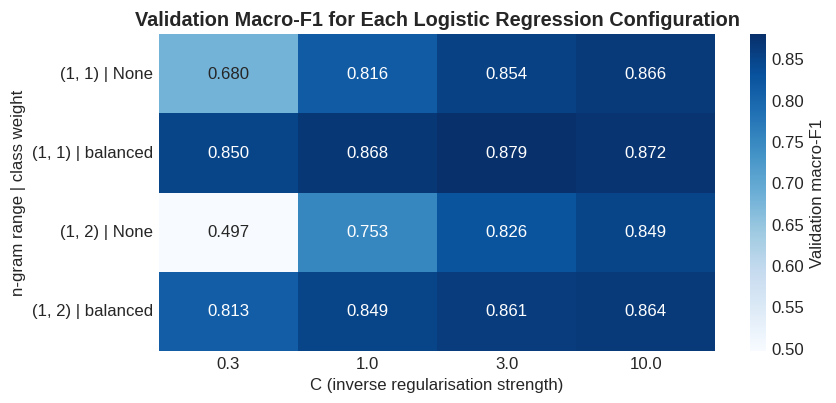

,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
model,,,,,
Majority-class baseline,0.3520,0.0587,0.1667,0.0868,0.1833
"Naive Bayes + TF-IDF (1,1)",0.6785,0.7036,0.4247,0.4243,0.6062
Logistic Regression + TF-IDF (selected),0.9005,0.8595,0.9041,0.8790,0.9017


**Selected configuration (by validation macro-F1):** `ngram_range=(1, 1)`, `C=3`, `class_weight=balanced` → validation macro-F1 = **0.8790**, accuracy = **0.9005**. Vocabulary size = 7,226 features. Improvement over Naive Bayes: **+0.4547** macro-F1; over the majority baseline: **+0.7922**.

In [31]:
best = grid_df.iloc[0]
BEST_NGRAM, BEST_C, BEST_CW = best["_key"]
final_model = fitted[best["_key"]]          # already trained on the cleaned training set only
val_results.append({"model": f"Logistic Regression + TF-IDF (selected)", **score(y_val, final_model.predict(X_val))})

# Heatmap of the grid
pivot = grid_df.assign(config=grid_df["ngram_range"] + " | " + grid_df["class_weight"]).pivot(index="config", columns="C", values="macro_f1")
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="Blues", ax=ax, cbar_kws={"label": "Validation macro-F1"})
ax.set_title("Validation Macro-F1 for Each Logistic Regression Configuration")
ax.set_xlabel("C (inverse regularisation strength)"); ax.set_ylabel("n-gram range | class weight")
plt.tight_layout(); plt.show()

val_compare = pd.DataFrame(val_results).set_index("model").round(4)
display(val_compare)
vocab_size = len(final_model.named_steps["tfidf"].vocabulary_)
display(Markdown(
    f"**Selected configuration (by validation macro-F1):** `ngram_range={BEST_NGRAM}`, `C={BEST_C:g}`, "
    f"`class_weight={BEST_CW}` → validation macro-F1 = **{best['macro_f1']:.4f}**, accuracy = **{best['accuracy']:.4f}**. "
    f"Vocabulary size = {vocab_size:,} features. "
    f"Improvement over Naive Bayes: **{best['macro_f1'] - val_compare.loc['Naive Bayes + TF-IDF (1,1)','macro_f1']:+.4f}** macro-F1; "
    f"over the majority baseline: **{best['macro_f1'] - val_compare.loc['Majority-class baseline','macro_f1']:+.4f}**."))

**Interpretation:**
- The **majority baseline** has a very low macro-F1: predicting one class for everything is useless for the other emotions.
- **Naive Bayes** is also weak on macro-F1. With imbalanced classes it strongly favours the frequent emotions and rarely predicts the rare ones.
- **Logistic Regression** is much stronger. The heatmap shows which settings helped. Class weighting and the n-gram choice were decided by the validation data, not by assumption.
- The selected model is **fixed now**. It is trained on the training set only, and the next section evaluates it once on the untouched test set.



# 11. Model Evaluation (Test Set)

The final model is now evaluated **once** on the official test set. We report:
- **Accuracy:** share of texts classified correctly.
- **Precision:** of the texts predicted as emotion X, how many really are X?
- **Recall:** of the texts that really are X, how many did we find?
- **F1-score:** the harmonic mean of precision and recall.
- **Macro average:** every emotion counts equally, so rare emotions matter as much as common ones. This is our **main metric**.
- **Weighted average:** each emotion is weighted by its number of test examples.

In [32]:
test_df = data["test"].copy()
test_df["predicted"] = final_model.predict(X_test)
proba = final_model.predict_proba(X_test)
MODEL_CLASSES = list(final_model.classes_)          # column order of predict_proba
test_df["confidence"] = proba.max(axis=1)
test_df["correct"] = test_df["emotion"] == test_df["predicted"]

TEST_METRICS = score(test_df["emotion"], test_df["predicted"])
test_compare = pd.DataFrame({
    "Majority-class baseline": score(y_test, dummy.predict(X_test)),
    "Naive Bayes + TF-IDF": score(y_test, nb.predict(X_test)),
    "Logistic Regression + TF-IDF (final)": TEST_METRICS,
}).T.round(4)
print("=== Test-set results (model selection was done on validation; baselines shown for context) ===")
display(test_compare)

print("=== Classification report: final model, test set ===")
print(classification_report(test_df["emotion"], test_df["predicted"], labels=LABEL_NAMES, digits=3, zero_division=0))
report_df = pd.DataFrame(classification_report(test_df["emotion"], test_df["predicted"], labels=LABEL_NAMES,
                                               output_dict=True, zero_division=0)).T
per_class = report_df.loc[LABEL_NAMES, ["precision", "recall", "f1-score", "support"]]

=== Test-set results (model selection was done on validation; baselines shown for context) ===


,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
Majority-class baseline,0.3475,0.0579,0.1667,0.0860,0.1792
Naive Bayes + TF-IDF,0.6925,0.7071,0.4308,0.4353,0.6272
Logistic Regression + TF-IDF (final),0.8870,0.8227,0.8781,0.8450,0.8900


=== Classification report: final model, test set ===
              precision    recall  f1-score   support

     sadness      0.959     0.895     0.926       581
         joy      0.945     0.883     0.913       695
        love      0.686     0.906     0.780       159
       anger      0.868     0.909     0.888       275
        fear      0.865     0.857     0.861       224
    surprise      0.614     0.818     0.701        66

    accuracy                          0.887      2000
   macro avg      0.823     0.878     0.845      2000
weighted avg      0.898     0.887     0.890      2000



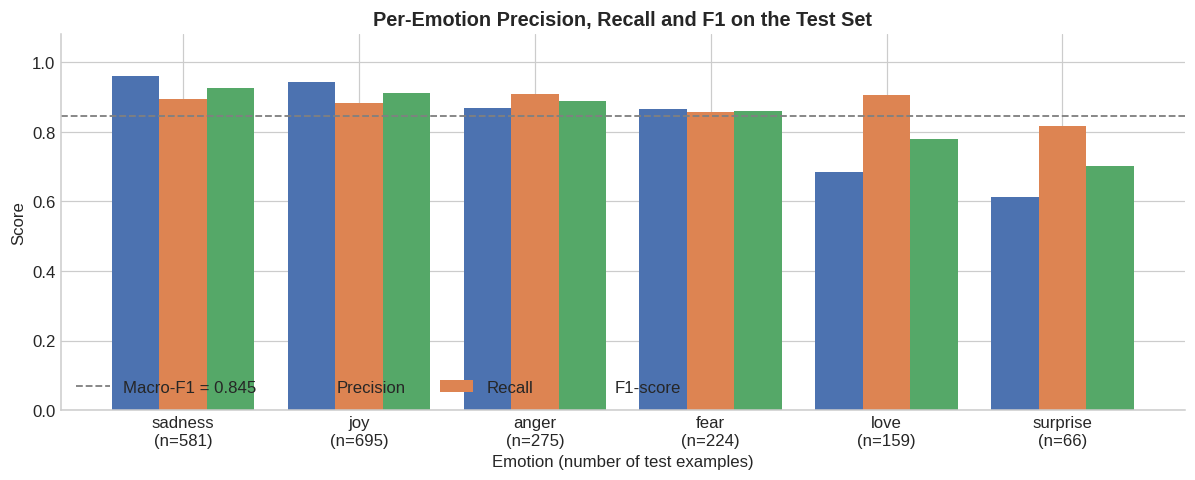

In [33]:
fig, ax = plt.subplots(figsize=(11, 4.5))
pc = per_class.sort_values("f1-score", ascending=False)
x = np.arange(len(pc)); w = 0.27
for i, (m, c) in enumerate(zip(["precision", "recall", "f1-score"], ["#4C72B0", "#DD8452", "#55A868"])):
    ax.bar(x + (i - 1) * w, pc[m], width=w, label=m.capitalize(), color=c)
ax.set_xticks(x); ax.set_xticklabels([f"{e}\n(n={int(n)})" for e, n in zip(pc.index, pc["support"])])
ax.axhline(TEST_METRICS["macro_f1"], color="grey", ls="--", lw=1.2, label=f"Macro-F1 = {TEST_METRICS['macro_f1']:.3f}")
ax.set_ylim(0, 1.08); ax.set_title("Per-Emotion Precision, Recall and F1 on the Test Set")
ax.set_xlabel("Emotion (number of test examples)"); ax.set_ylabel("Score"); ax.legend(loc="lower left", ncol=4)
plt.tight_layout(); plt.show()

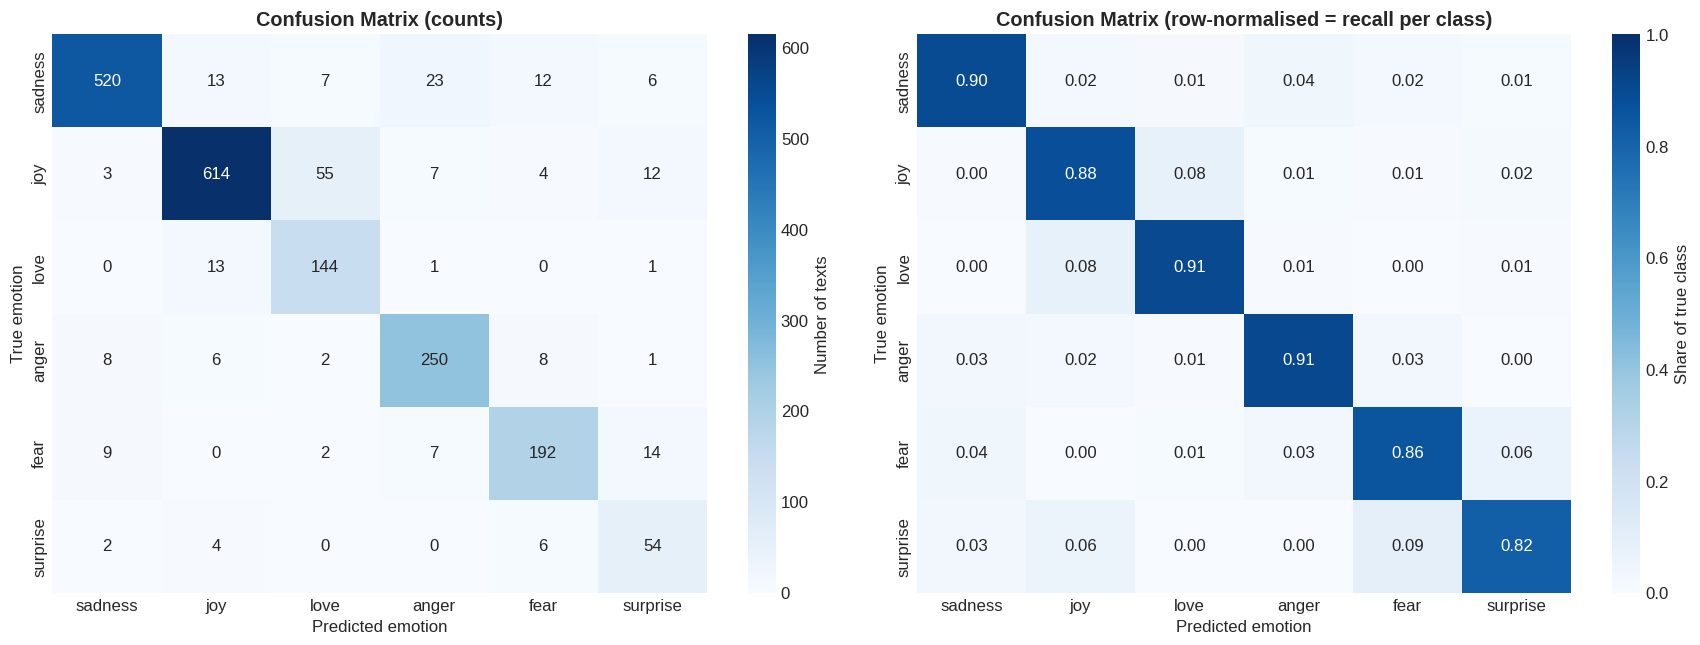

In [34]:
cm = confusion_matrix(test_df["emotion"], test_df["predicted"], labels=LABEL_NAMES)
cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[0],
            cbar_kws={"label": "Number of texts"})
axes[0].set_title("Confusion Matrix (counts)")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES, ax=axes[1],
            vmin=0, vmax=1, cbar_kws={"label": "Share of true class"})
axes[1].set_title("Confusion Matrix (row-normalised = recall per class)")
for ax in axes:
    ax.set_xlabel("Predicted emotion"); ax.set_ylabel("True emotion")
plt.tight_layout(); plt.show()

### Model Performance Interpretation

In [35]:
off = pd.DataFrame(cm, index=LABEL_NAMES, columns=LABEL_NAMES).stack().rename("count").reset_index()
off.columns = ["true", "predicted", "count"]
off = off[off["true"] != off["predicted"]].sort_values("count", ascending=False)
TOP_CONFUSIONS = off.head(3).reset_index(drop=True)
best_cls, worst_cls = per_class["f1-score"].idxmax(), per_class["f1-score"].idxmin()
low_prec = per_class["precision"].idxmin()

conf_lines = "\n".join(f"  - **{r.true} → {r.predicted}**: {r.count} texts "
                       f"({r.count / per_class.loc[r.true,'support'] * 100:.1f}% of true *{r.true}*)"
                       for r in TOP_CONFUSIONS.itertuples())
display(Markdown(f'''
**Overall performance.** On the {len(test_df):,}-text test set the model reaches **accuracy = {TEST_METRICS['accuracy']:.3f}**,
**macro-F1 = {TEST_METRICS['macro_f1']:.3f}** and **weighted-F1 = {TEST_METRICS['weighted_f1']:.3f}**
(macro precision {TEST_METRICS['macro_precision']:.3f}, macro recall {TEST_METRICS['macro_recall']:.3f}).
The gap between accuracy and macro-F1 shows that the rarer emotions are handled less well than the common ones.

**Strong / weak classes.** Best F1: **{best_cls}** ({per_class.loc[best_cls,'f1-score']:.3f}, n={int(per_class.loc[best_cls,'support'])}).
Weakest F1: **{worst_cls}** ({per_class.loc[worst_cls,'f1-score']:.3f}, n={int(per_class.loc[worst_cls,'support'])}).
Lowest precision: **{low_prec}** ({per_class.loc[low_prec,'precision']:.3f}). The model predicts this class too often, which is a likely
side-effect of class weighting (rare classes are given more weight, so they are predicted more readily).

**Most frequent confusions** (true → predicted):
{conf_lines}
'''))


**Overall performance.** On the 2,000-text test set the model reaches **accuracy = 0.887**,
**macro-F1 = 0.845** and **weighted-F1 = 0.890**
(macro precision 0.823, macro recall 0.878).
The gap between accuracy and macro-F1 shows that the rarer emotions are handled less well than the common ones.

**Strong / weak classes.** Best F1: **sadness** (0.926, n=581).
Weakest F1: **surprise** (0.701, n=66).
Lowest precision: **surprise** (0.614). The model predicts this class too often, which is a likely
side-effect of class weighting (rare classes are given more weight, so they are predicted more readily).

**Most frequent confusions** (true → predicted):
  - **joy → love**: 55 texts (7.9% of true *joy*)
  - **sadness → anger**: 23 texts (4.0% of true *sadness*)
  - **fear → surprise**: 14 texts (6.2% of true *fear*)


**Reading the confusions:** The largest confusions are between emotions that are **semantically close** (for example positive emotions with each other, or different negative emotions with each other). These are errors a human reader could also plausibly make on a short text. The next section looks at the actual sentences behind these errors.



# 12. Error Analysis

We examine the **misclassified test texts**, grouped by the most common *true → predicted* pairs, and compare the model's confidence on correct vs. incorrect predictions.

In [36]:
errors = test_df[~test_df["correct"]].copy()
print(f"Misclassified test texts: {len(errors)} of {len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)")
pair_counts = errors.groupby(["emotion", "predicted"]).size().rename("count").sort_values(ascending=False).reset_index()
pair_counts.columns = ["actual", "predicted", "count"]
pair_counts["share of all errors %"] = (pair_counts["count"] / len(errors) * 100).round(1)
display(pair_counts.head(8))

Misclassified test texts: 226 of 2000 (11.3%)


,actual,predicted,count,share of all errors %
0,joy,love,55,24.3
1,sadness,anger,23,10.2
2,fear,surprise,14,6.2
3,love,joy,13,5.8
4,sadness,joy,13,5.8
5,sadness,fear,12,5.3
6,joy,surprise,12,5.3
7,fear,sadness,9,4.0


In [37]:
for r in TOP_CONFUSIONS.itertuples():
    sub = errors[(errors["emotion"] == r.true) & (errors["predicted"] == r.predicted)]
    print(f"\n==================  Actual: {r.true.upper()}  →  Predicted: {r.predicted.upper()}  ({len(sub)} errors)  ==================")
    for _, row in sub.sample(min(4, len(sub)), random_state=SEED).iterrows():
        print(f"  [confidence {row['confidence']:.2f}]  {row['text']}")


==================  Actual: JOY  →  Predicted: LOVE  (55 errors)  ==================
  [confidence 0.98]  i feel that passionate about
  [confidence 0.77]  i could feel his breath on me and smell the sweet scent of him
  [confidence 0.65]  ive come to feel about a supporting character in one of my all time favorite films giant
  [confidence 0.93]  i feel accepted and loved by a community of derby girls that i helped to create

==================  Actual: SADNESS  →  Predicted: ANGER  (23 errors)  ==================
  [confidence 0.55]  i started questioning god feeling worthless and even jealous of others that come by parenthood so easily
  [confidence 0.69]  i want to feel less stressed
  [confidence 0.51]  i hope everyone can help with charity work without feeling stressed about such things
  [confidence 0.29]  i sit in the same hostel i did nearly two months ago this time wearing a jacket and feeling as if my toes might be a little numb from the cold

==================  Actual: FE

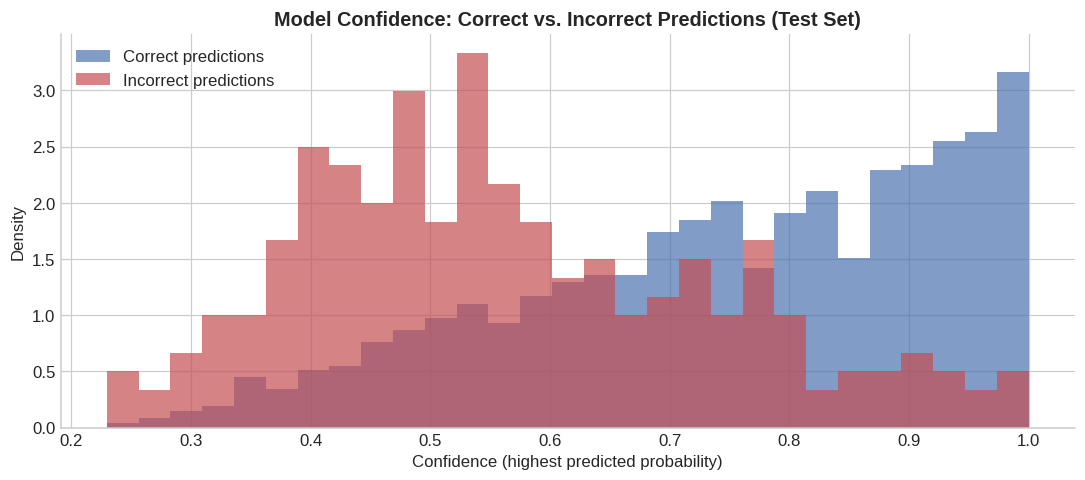

,count,mean,50%
correct,,,
incorrect,226.0,0.565,0.542
correct,1774.0,0.754,0.783


**Auto-summary:** mean confidence is **0.75** on correct predictions vs **0.56** on errors. **21** errors (9.3% of errors) were made with confidence ≥ 0.80.

Examples of HIGH-confidence errors (confidence ≥ 0.80):


,text,emotion,predicted,confidence
1842,i feel so amazing musicjuzz,joy,surprise,0.99
1154,i feel that passionate about,joy,love,0.98
877,i feel respected and secure where i can journey toward loving and be loved in return,joy,love,0.97
1943,i didn t mean to get angry with you bommie i just can t control my feelings hellip i just hated myself why i am like this the dara who can t get over with t...,sadness,anger,0.96
1698,i work well with almost every client ive ever been in contact with because i know what it means to feel depressed angry frustrated irritated hopeless and ap...,sadness,anger,0.95
867,i was truly surprised and feel quite honored,joy,surprise,0.95
576,i feel accepted and loved by a community of derby girls that i helped to create,joy,love,0.93
1066,i asked some girls what it meant to them to be valued and for the most part the response was that they felt valued when the people around them made them fee...,joy,love,0.92


In [38]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.linspace(test_df["confidence"].min(), 1, 30)
ax.hist(test_df.loc[test_df["correct"], "confidence"], bins=bins, alpha=0.7, label="Correct predictions", color="#4C72B0", density=True)
ax.hist(test_df.loc[~test_df["correct"], "confidence"], bins=bins, alpha=0.7, label="Incorrect predictions", color="#C44E52", density=True)
ax.set_title("Model Confidence: Correct vs. Incorrect Predictions (Test Set)")
ax.set_xlabel("Confidence (highest predicted probability)"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

conf_summary = test_df.groupby("correct")["confidence"].describe()[["count", "mean", "50%"]].round(3)
conf_summary.index = conf_summary.index.map({True: "correct", False: "incorrect"})
display(conf_summary)
HIGH_CONF_ERRORS = errors[errors["confidence"] >= 0.8]
display(Markdown(f"**Auto-summary:** mean confidence is **{conf_summary.loc['correct','mean']:.2f}** on correct predictions vs "
                 f"**{conf_summary.loc['incorrect','mean']:.2f}** on errors. **{len(HIGH_CONF_ERRORS)}** errors "
                 f"({len(HIGH_CONF_ERRORS)/len(errors)*100:.1f}% of errors) were made with confidence ≥ 0.80."))
print("Examples of HIGH-confidence errors (confidence ≥ 0.80):")
display(HIGH_CONF_ERRORS.sort_values("confidence", ascending=False)[["text", "emotion", "predicted", "confidence"]].head(8).round(2))

**Error patterns (based on the examples above):**
1. **Related-emotion confusions.** Many errors are between emotions that overlap in meaning. Texts about feeling *accepted, loved, respected or valued* are labelled *joy* but predicted *love*. Texts about feeling *stressed* are labelled *sadness* but predicted *anger*. Texts about feeling *overwhelmed* are labelled *fear* but predicted *surprise* (Section 14 shows *overwhelmed* is one of the strongest *surprise* features).
2. **Mixed or implicit emotion.** Several misclassified texts describe a situation rather than naming a feeling, or mention words from more than one emotion. A bag-of-words model then follows whichever words carry the largest weights.
3. **Confident errors often contain a strong "cue word" of the predicted class.** In the high-confidence errors, the text usually contains a word the model strongly associates with the predicted emotion, while the gold label points elsewhere. Some of these cases look like **debatable labels** rather than clear model mistakes, which fits the label noise found in Section 5.
4. **Lower confidence on errors.** Errors have noticeably lower average confidence than correct predictions, so the probability output is a useful (though imperfect) warning signal.

*These patterns come from inspecting a sample of errors. They are observations, not proven causes.* They lead directly into the audit (does performance differ by text style?) and the explainability analysis (which words drive predictions?).


# 13. Performance / Bias Audit

**Goal:** check whether the model performs **equally well on different kinds of text**, not just on average.

This dataset contains **no demographic information** (no author age, gender, region, etc.). We therefore do **not** invent demographic groups. Instead, we audit two **measurable text subgroups/styles** motivated by the EDA:

| Audit dimension | Subgroups | Exact, reproducible definition | Why it is meaningful |
|---|---|---|---|
| **1. Text length** | *Short* vs *Long* | Word count of the processed text ≤ vs > the **training-set median** word count | Short texts give little context; long texts can mix several emotions. EDA showed a wide, skewed length distribution. |
| **2. Negation style** | *With negation* vs *Without negation* | Text contains ≥ 1 word from the documented `NEGATION_WORDS` list (Section 4.J) | Negation can reverse an emotion (*"not happy"*), and a bag-of-words model does not model word order. EDA showed ~¼ of texts contain negation. |

**Metrics per subgroup:** number of samples, accuracy, macro-precision, macro-recall, **macro-F1 (main comparison metric)**, and weighted-F1.
**Uncertainty:** a **bootstrap 95% confidence interval** (1,000 resamples) for the macro-F1 difference between the two subgroups, so we can see whether a gap is larger than random variation.
All audits use the **test set**, and thresholds come from the **training set**.

In [39]:
LENGTH_THRESHOLD = float(train_df["processed_text"].str.split().str.len().median())   # from TRAINING data
test_df["n_words"] = test_df["processed_text"].str.split().str.len()
SHORT_LABEL = f"Short (≤{LENGTH_THRESHOLD:.0f} words)"
LONG_LABEL  = f"Long (>{LENGTH_THRESHOLD:.0f} words)"
test_df["length_group"] = np.where(test_df["n_words"] <= LENGTH_THRESHOLD, SHORT_LABEL, LONG_LABEL)
test_df["negation_group"] = np.where(test_df["processed_text"].str.contains(NEGATION_PATTERN),
                                     "With negation", "Without negation")
print(f"Length threshold (training-set median word count): {LENGTH_THRESHOLD:.0f}")

def group_metrics(df, group_col, order):
    rows = []
    for g in order:
        sub = df[df[group_col] == g]
        rows.append({"subgroup": g, "n_samples": len(sub), "share_of_test_%": round(len(sub) / len(df) * 100, 1),
                     **{k: round(v, 4) for k, v in score(sub["emotion"], sub["predicted"]).items()}})
    return pd.DataFrame(rows).set_index("subgroup")

def bootstrap_diff(df, group_col, g_a, g_b, n_boot=1000, seed=SEED):
    # Bootstrap 95% CI for macro-F1(g_a) - macro-F1(g_b), resampling each subgroup independently.
    rng = np.random.default_rng(seed)
    a, b = df[df[group_col] == g_a], df[df[group_col] == g_b]
    ya, pa, yb, pb = a["emotion"].values, a["predicted"].values, b["emotion"].values, b["predicted"].values
    mf1 = lambda y, p: f1_score(y, p, labels=LABEL_NAMES, average="macro", zero_division=0)
    observed = mf1(ya, pa) - mf1(yb, pb)
    diffs = []
    for _ in range(n_boot):
        ia, ib = rng.integers(0, len(a), len(a)), rng.integers(0, len(b), len(b))
        diffs.append(mf1(ya[ia], pa[ia]) - mf1(yb[ib], pb[ib]))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return observed, lo, hi

Length threshold (training-set median word count): 17


## 13.1 Audit Group / Style 1: Short vs. Long texts

In [40]:
LEN_ORDER = [SHORT_LABEL, LONG_LABEL]
audit_len = group_metrics(test_df, "length_group", LEN_ORDER)
display(audit_len)
LEN_DIFF, LEN_LO, LEN_HI = bootstrap_diff(test_df, "length_group", SHORT_LABEL, LONG_LABEL)
display(Markdown(f"**Macro-F1 difference (Short − Long) = {LEN_DIFF:+.4f}**, bootstrap 95% CI [{LEN_LO:+.4f}, {LEN_HI:+.4f}] → "
                 + ("the interval **excludes 0**, so the gap is unlikely to be due to random sampling alone."
                    if (LEN_LO > 0 or LEN_HI < 0) else "the interval **includes 0**, so the gap may be due to chance.")))

,n_samples,share_of_test_%,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
subgroup,,,,,,,
Short (≤17 words),1035,51.7,0.9208,0.8637,0.9195,0.8866,0.9230
Long (>17 words),965,48.2,0.8508,0.7795,0.8337,0.8006,0.8546


**Macro-F1 difference (Short − Long) = +0.0860**, bootstrap 95% CI [+0.0463, +0.1279] → the interval **excludes 0**, so the gap is unlikely to be due to random sampling alone.

## 13.2 Audit Group / Style 2: Texts with vs. without negation

In [41]:
NEG_ORDER = ["With negation", "Without negation"]
audit_neg = group_metrics(test_df, "negation_group", NEG_ORDER)
display(audit_neg)
NEG_DIFF, NEG_LO, NEG_HI = bootstrap_diff(test_df, "negation_group", "With negation", "Without negation")
display(Markdown(f"**Macro-F1 difference (With − Without negation) = {NEG_DIFF:+.4f}**, bootstrap 95% CI [{NEG_LO:+.4f}, {NEG_HI:+.4f}] → "
                 + ("the interval **excludes 0**, so the gap is unlikely to be due to random sampling alone."
                    if (NEG_LO > 0 or NEG_HI < 0) else "the interval **includes 0**, so the gap may be due to chance.")))

,n_samples,share_of_test_%,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
subgroup,,,,,,,
With negation,488,24.4,0.8484,0.7777,0.8399,0.8015,0.8525
Without negation,1512,75.6,0.8995,0.8366,0.8907,0.8587,0.9022


**Macro-F1 difference (With − Without negation) = -0.0572**, bootstrap 95% CI [-0.1180, -0.0029] → the interval **excludes 0**, so the gap is unlikely to be due to random sampling alone.

## 13.3 Performance Comparison

n_samples  share_of_test_%  accuracy  macro_precision  macro_recall  macro_f1  weighted_f1
               subgroup                                                                                                     
1. Text length Short (≤17 words)       1035             51.7    0.9208           0.8637        0.9195    0.8866       0.9230
               Long (>17 words)         965             48.2    0.8508           0.7795        0.8337    0.8006       0.8546
2. Negation    With negation            488             24.4    0.8484           0.7777        0.8399    0.8015       0.8525
               Without negation        1512             75.6    0.8995           0.8366        0.8907    0.8587       0.9022

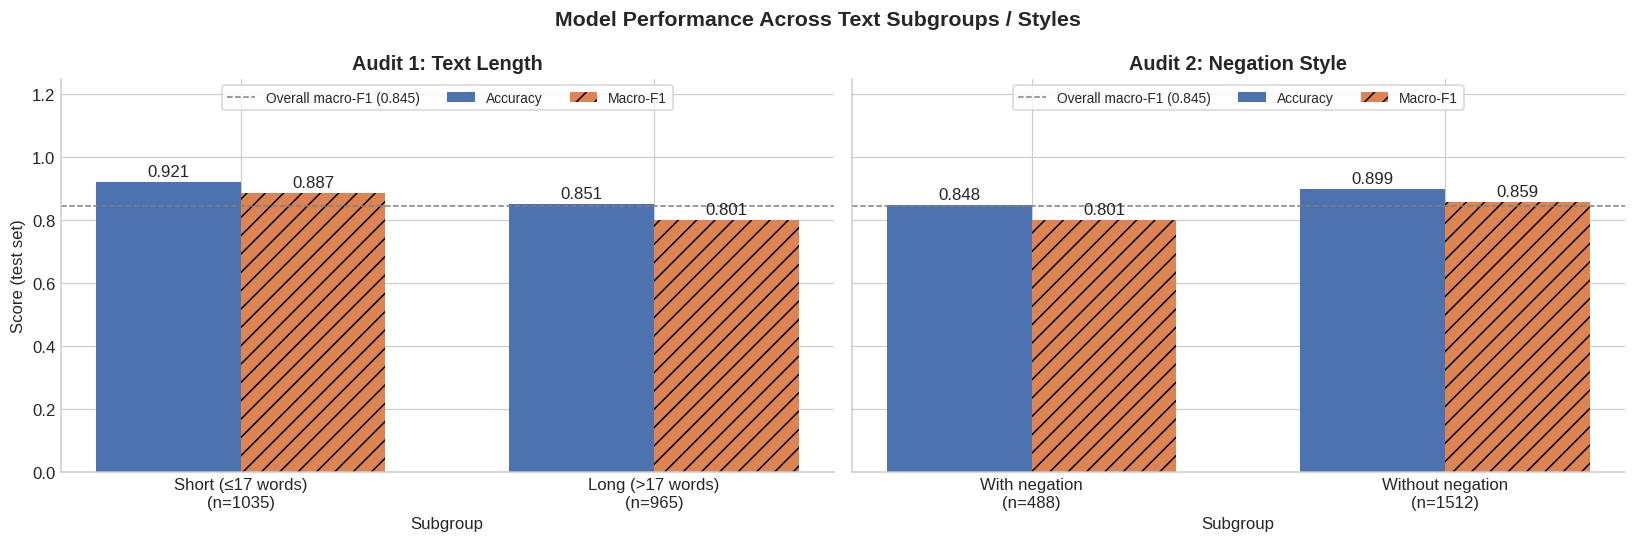

In [42]:
audit_all = pd.concat({"1. Text length": audit_len, "2. Negation": audit_neg})
display(audit_all[["n_samples", "share_of_test_%", "accuracy", "macro_precision", "macro_recall", "macro_f1", "weighted_f1"]])

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (title, tab) in zip(axes, [("Audit 1: Text Length", audit_len), ("Audit 2: Negation Style", audit_neg)]):
    x = np.arange(len(tab)); w = 0.35
    b1 = ax.bar(x - w/2, tab["accuracy"], w, label="Accuracy", color="#4C72B0")
    b2 = ax.bar(x + w/2, tab["macro_f1"], w, label="Macro-F1", color="#DD8452", hatch="//")
    ax.bar_label(b1, fmt="%.3f", padding=2); ax.bar_label(b2, fmt="%.3f", padding=2)
    ax.axhline(TEST_METRICS["macro_f1"], color="grey", ls="--", lw=1, label=f"Overall macro-F1 ({TEST_METRICS['macro_f1']:.3f})")
    ax.set_xticks(x); ax.set_xticklabels([f"{g}\n(n={n})" for g, n in zip(tab.index, tab["n_samples"])])
    ax.set_title(title); ax.set_xlabel("Subgroup"); ax.set_ylim(0, 1.25); ax.legend(loc="upper center", ncol=3, fontsize=9, frameon=True)
axes[0].set_ylabel("Score (test set)")
plt.suptitle("Model Performance Across Text Subgroups / Styles", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()

### 13.4 Is the gap caused by a different emotion mix? (confounder check)
If one subgroup simply contains more of a "hard" emotion, its score would drop even if the text style itself is not the issue. We therefore check (a) the **emotion mix** of each subgroup, (b) the **per-emotion F1** inside each subgroup, and (c) whether the two audit dimensions **overlap** (e.g. are negated texts also longer?).

(a) Emotion mix of each subgroup (% of subgroup):


emotion                     sadness   joy  love  anger  fear  surprise
length   Short (≤17 words)     28.8  34.8   7.4   13.5  12.2       3.3
         Long (>17 words)      29.3  34.7   8.5   14.0  10.2       3.3
negation With negation         31.6  31.4   8.4   16.8   9.2       2.7
         Without negation      28.2  35.8   7.8   12.8  11.8       3.5

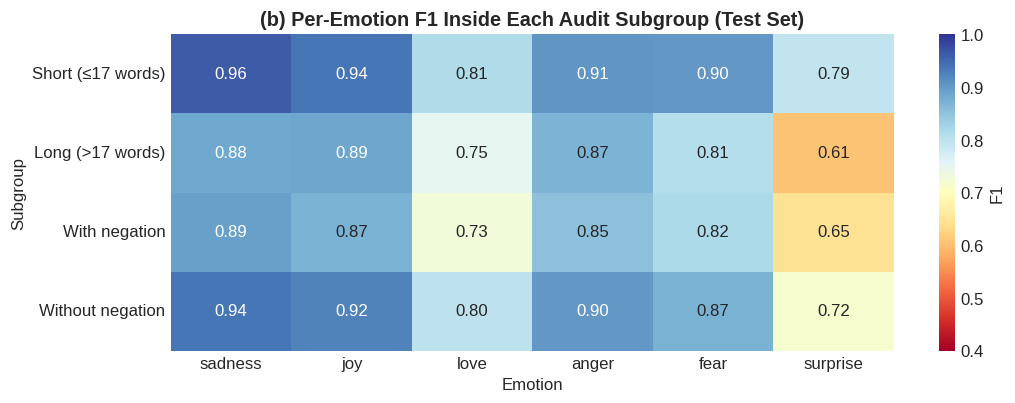

(c) Overlap of the two audit dimensions: macro-F1 (n) in each combination


/tmp/ipykernel_3509/2961680811.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inter = test_df.groupby(["length_group", "negation_group"]).apply(


negation_group,With negation,Without negation
length_group,,
Short (≤17 words),0.906 (n=137),0.889 (n=898)
Long (>17 words),0.779 (n=351),0.813 (n=614)


Share of texts with negation in each length group (%): {'Short (≤17 words)': 13.2, 'Long (>17 words)': 36.4}


**Confounder check result:** Overall negation gap (with − without) = **-0.057**. Within short texts it is **+0.017**; within long texts it is **-0.033**. Negated texts make up 36.4% of long texts but only 13.2% of short texts. → **Most of the overall negation gap is explained by negated texts being longer.** The audit alone is therefore only weak evidence of a negation-specific weakness; Section 15.1 tests negation directly with controlled sentences.

In [43]:
mix = pd.concat({
    "length": pd.crosstab(test_df["length_group"], test_df["emotion"], normalize="index").reindex(LEN_ORDER),
    "negation": pd.crosstab(test_df["negation_group"], test_df["emotion"], normalize="index").reindex(NEG_ORDER),
})[LABEL_NAMES].mul(100).round(1)
print("(a) Emotion mix of each subgroup (% of subgroup):")
display(mix)

pc_rows = {}
for col, order_ in [("length_group", LEN_ORDER), ("negation_group", NEG_ORDER)]:
    for g in order_:
        sub = test_df[test_df[col] == g]
        pc_rows[g] = pd.Series(f1_score(sub["emotion"], sub["predicted"], labels=LABEL_NAMES, average=None, zero_division=0),
                               index=LABEL_NAMES)
pc_f1 = pd.DataFrame(pc_rows).T
fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(pc_f1, annot=True, fmt=".2f", cmap="RdYlBu", vmin=0.4, vmax=1, ax=ax, cbar_kws={"label": "F1"})
ax.set_title("(b) Per-Emotion F1 Inside Each Audit Subgroup (Test Set)")
ax.set_xlabel("Emotion"); ax.set_ylabel("Subgroup")
plt.tight_layout(); plt.show()

print("(c) Overlap of the two audit dimensions: macro-F1 (n) in each combination")
inter = test_df.groupby(["length_group", "negation_group"]).apply(
    lambda s: f"{f1_score(s['emotion'], s['predicted'], labels=LABEL_NAMES, average='macro', zero_division=0):.3f} (n={len(s)})"
).unstack().reindex(index=LEN_ORDER, columns=NEG_ORDER)
display(inter)
neg_share_by_len = test_df.groupby("length_group")["negation_group"].apply(lambda s: (s == "With negation").mean() * 100).reindex(LEN_ORDER)
print("Share of texts with negation in each length group (%):", neg_share_by_len.round(1).to_dict())

# Negation gap WITHIN each length group (controls for length)
mf1 = lambda d: f1_score(d["emotion"], d["predicted"], labels=LABEL_NAMES, average="macro", zero_division=0)
NEG_WITHIN_LEN = {g: mf1(test_df[(test_df["length_group"] == g) & (test_df["negation_group"] == "With negation")])
                     - mf1(test_df[(test_df["length_group"] == g) & (test_df["negation_group"] == "Without negation")])
                  for g in LEN_ORDER}
overall_neg_gap = audit_neg.loc["With negation", "macro_f1"] - audit_neg.loc["Without negation", "macro_f1"]
NEG_CONFOUNDED = all(abs(v) < abs(overall_neg_gap) for v in NEG_WITHIN_LEN.values())
display(Markdown(
    f"**Confounder check result:** Overall negation gap (with − without) = **{overall_neg_gap:+.3f}**. "
    f"Within short texts it is **{NEG_WITHIN_LEN[SHORT_LABEL]:+.3f}**; within long texts it is **{NEG_WITHIN_LEN[LONG_LABEL]:+.3f}**. "
    f"Negated texts make up {neg_share_by_len[LONG_LABEL]:.1f}% of long texts but only {neg_share_by_len[SHORT_LABEL]:.1f}% of short texts. "
    + ("→ **Most of the overall negation gap is explained by negated texts being longer.** The audit alone is therefore only weak "
       "evidence of a negation-specific weakness; Section 15.1 tests negation directly with controlled sentences."
       if NEG_CONFOUNDED else
       "→ The negation gap **persists** after comparing texts of similar length, which supports a negation-specific weakness.")))

### 13.5 Supplementary: finer-grained length analysis
To check that the length finding is not an artefact of one cut-off, we split the test set into four length bands using **training-set quartiles**.

/tmp/ipykernel_3509/1243636328.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  band = test_df.groupby("length_band", observed=True).apply(lambda s: pd.Series({


,n,accuracy,macro_f1
1–11 words,593.0,0.924,0.883
12–17 words,442.0,0.916,0.897
18–25 words,450.0,0.889,0.835
26–max words,515.0,0.817,0.772


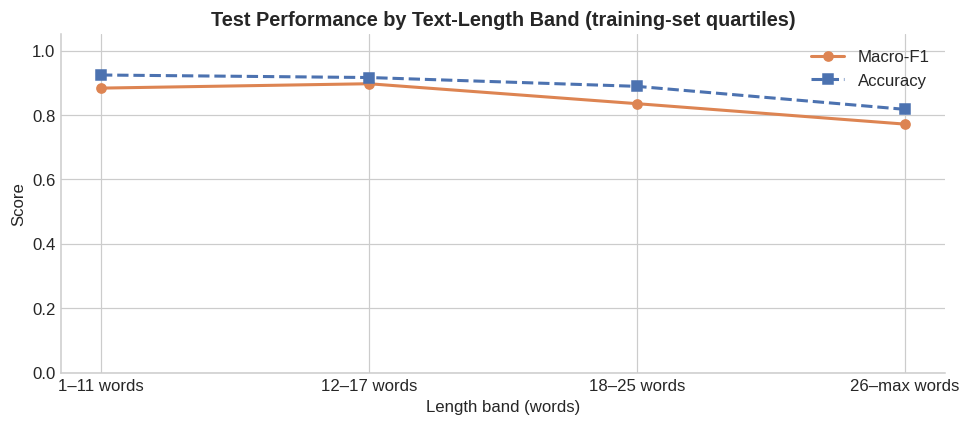

In [44]:
q_edges = np.unique(np.quantile(train_df["processed_text"].str.split().str.len(), [0, .25, .5, .75, 1]))
q_edges[0], q_edges[-1] = 0, np.inf
test_df["length_band"] = pd.cut(test_df["n_words"], bins=q_edges)
band = test_df.groupby("length_band", observed=True).apply(lambda s: pd.Series({
    "n": len(s), "accuracy": accuracy_score(s["emotion"], s["predicted"]),
    "macro_f1": f1_score(s["emotion"], s["predicted"], labels=LABEL_NAMES, average="macro", zero_division=0)}))
band.index = [f"{int(i.left)+1}–{int(i.right) if np.isfinite(i.right) else 'max'} words" for i in band.index]
display(band.round(3))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(band.index, band["macro_f1"], marker="o", lw=2, label="Macro-F1", color="#DD8452")
ax.plot(band.index, band["accuracy"], marker="s", lw=2, ls="--", label="Accuracy", color="#4C72B0")
ax.set_ylim(0, 1.05); ax.set_title("Test Performance by Text-Length Band (training-set quartiles)")
ax.set_xlabel("Length band (words)"); ax.set_ylabel("Score"); ax.legend()
plt.tight_layout(); plt.show()

### 13.6 Key audit finding (auto-generated from the results)

In [45]:
s_f1, l_f1 = audit_len.loc[SHORT_LABEL, "macro_f1"], audit_len.loc[LONG_LABEL, "macro_f1"]
n_f1, nn_f1 = audit_neg.loc["With negation", "macro_f1"], audit_neg.loc["Without negation", "macro_f1"]
len_sig = LEN_LO > 0 or LEN_HI < 0
neg_sig = NEG_LO > 0 or NEG_HI < 0
if abs(LEN_DIFF) >= abs(NEG_DIFF):
    KEY_AUDIT_FINDING = (f"Macro-F1 on {'short' if s_f1 > l_f1 else 'long'} texts ({max(s_f1, l_f1):.3f}) was higher than on "
                         f"{'long' if s_f1 > l_f1 else 'short'} texts ({min(s_f1, l_f1):.3f}), a gap of {abs(LEN_DIFF):.3f} "
                         f"(95% CI of the difference [{LEN_LO:+.3f}, {LEN_HI:+.3f}]).")
else:
    KEY_AUDIT_FINDING = (f"Macro-F1 on texts {'without' if nn_f1 > n_f1 else 'with'} negation ({max(n_f1, nn_f1):.3f}) was higher than on texts "
                         f"{'with' if nn_f1 > n_f1 else 'without'} negation ({min(n_f1, nn_f1):.3f}), a gap of {abs(NEG_DIFF):.3f} "
                         f"(95% CI [{NEG_LO:+.3f}, {NEG_HI:+.3f}]).")
NEG_NOTE = (" Most of this gap is explained by negated texts being longer (Section 13.4)." if NEG_CONFOUNDED
            else " The gap persists within length groups (Section 13.4).")
SECOND_AUDIT_FINDING = (f"Negation: with = {n_f1:.3f} vs without = {nn_f1:.3f} (diff {NEG_DIFF:+.3f}, 95% CI [{NEG_LO:+.3f}, {NEG_HI:+.3f}])." + NEG_NOTE
                        if abs(LEN_DIFF) >= abs(NEG_DIFF) else
                        f"Length: short = {s_f1:.3f} vs long = {l_f1:.3f} (diff {LEN_DIFF:+.3f}, 95% CI [{LEN_LO:+.3f}, {LEN_HI:+.3f}]).")
display(Markdown(f'''
| | Audit 1: Text length | Audit 2: Negation |
|---|---|---|
| **Observed performance difference** | Short ({audit_len.loc[SHORT_LABEL,'n_samples']} texts) macro-F1 = **{s_f1:.3f}**; Long ({audit_len.loc[LONG_LABEL,'n_samples']} texts) macro-F1 = **{l_f1:.3f}**; difference {LEN_DIFF:+.3f} | With negation ({audit_neg.loc['With negation','n_samples']} texts) macro-F1 = **{n_f1:.3f}**; Without ({audit_neg.loc['Without negation','n_samples']} texts) macro-F1 = **{nn_f1:.3f}**; difference {NEG_DIFF:+.3f} |
| **Statistical uncertainty** | 95% CI [{LEN_LO:+.3f}, {LEN_HI:+.3f}] → {"excludes 0" if len_sig else "includes 0"} | 95% CI [{NEG_LO:+.3f}, {NEG_HI:+.3f}] → {"excludes 0" if neg_sig else "includes 0"} |
| **After controlling for the other dimension** | Consistent decline across four length bands (13.5) | Within short: {NEG_WITHIN_LEN[SHORT_LABEL]:+.3f}; within long: {NEG_WITHIN_LEN[LONG_LABEL]:+.3f} → {"mostly explained by length" if NEG_CONFOUNDED else "persists"} |

**🔑 Key audit finding:** {KEY_AUDIT_FINDING}
'''))


| | Audit 1: Text length | Audit 2: Negation |
|---|---|---|
| **Observed performance difference** | Short (1035 texts) macro-F1 = **0.887**; Long (965 texts) macro-F1 = **0.801**; difference +0.086 | With negation (488 texts) macro-F1 = **0.801**; Without (1512 texts) macro-F1 = **0.859**; difference -0.057 |
| **Statistical uncertainty** | 95% CI [+0.046, +0.128] → excludes 0 | 95% CI [-0.118, -0.003] → excludes 0 |
| **After controlling for the other dimension** | Consistent decline across four length bands (13.5) | Within short: +0.017; within long: -0.033 → mostly explained by length |

**🔑 Key audit finding:** Macro-F1 on short texts (0.887) was higher than on long texts (0.801), a gap of 0.086 (95% CI of the difference [+0.046, +0.128]).


### Interpretation, with care

**Observed performance difference.** The tables and chart above show the measured gap for each dimension, with a bootstrap confidence interval.

**Possible interpretation (a hypothesis, not a proven cause):**
- **Length:** Contrary to the intuition that short texts are hardest, the tables and the length-band chart show that **performance falls as texts get longer** in this dataset. A plausible reason, consistent with the error analysis, is that long texts more often mention **several feelings or situations**. TF-IDF + Logistic Regression then adds up competing word cues without understanding which one is the main emotion.
- **Negation:** Overall, texts containing negation score lower. However, the confounder check (13.4) shows that negated texts are much more common among long texts, and **when texts of similar length are compared, the negation gap becomes small or even reverses**. We therefore do **not** claim from the audit alone that negation causes the drop. Negation is still a plausible weakness, because a bag-of-words model sees *"not"* and *"happy"* as separate words, so Section 15.1 tests it **directly** with controlled sentence pairs.

**Limitations and uncertainty of this audit:**
- The two dimensions **overlap**: negated texts tend to be longer (see 13.4c). The 2×2 table helps separate them, but its cells are smaller and noisier (e.g. short + negated has only ~140 texts).
- The emotion mix differs slightly between subgroups (13.4a), and small classes have few examples per subgroup, so per-class F1 inside subgroups is noisy.
- These are **text-style** subgroups. Because the dataset has no demographic data, this audit says **nothing** about fairness towards groups of *people*.
- The negation detector is a **word list**, so it can miss unusual negations and flag words like *"no"* in non-negating uses.


# 14. Explainability Analysis

**Method: model coefficients (top features), global and local.** This is the "top features" option from the guideline, and it is the natural choice for a linear model on TF-IDF:

- **Global explanation:** Logistic Regression learns one weight per (word, emotion). The words with the largest positive weights for an emotion are the words that most strongly push the model toward that emotion.
- **Local explanation (one sentence):** For a given text, each word's **contribution** to the predicted emotion is

  `contribution(word) = TF-IDF value of the word in this text × (weight of word for predicted emotion − average weight of word across emotions)`

  Subtracting the average weight is valid because softmax only depends on **differences** between emotion scores. A positive contribution means *"this word pushed the prediction toward this emotion rather than the others"*.
- **Sanity check (occlusion test):** We delete the single most influential word from correctly classified test texts and measure how often the prediction changes. This tells us how much the model **depends on individual keywords**.

**Why this method instead of SHAP/LIME?** For a linear model these contributions are **exact**: they are the model's own arithmetic, not an approximation. They are also fast, easy to visualise and easy to explain. SHAP/LIME are designed mainly for black-box models and would add approximation and runtime without new insight here.

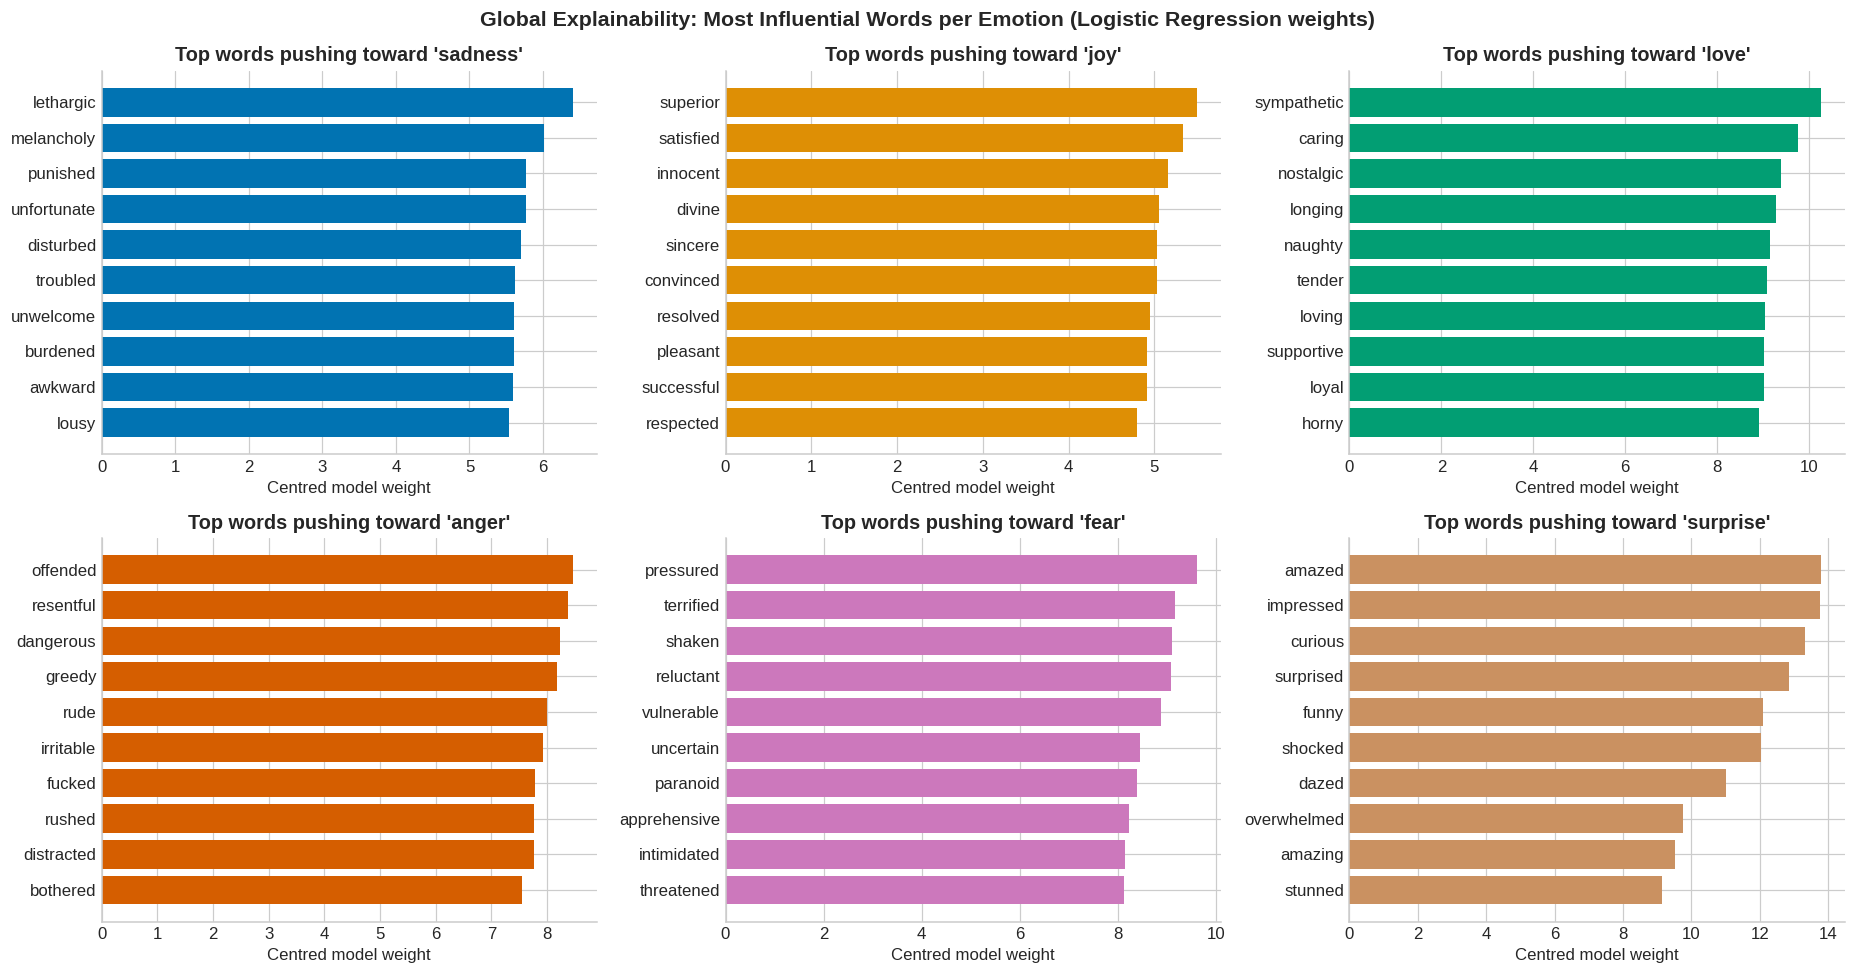

,sadness,joy,love,anger,fear,surprise
rank,,,,,,
1,lethargic,superior,sympathetic,offended,pressured,amazed
2,melancholy,satisfied,caring,resentful,terrified,impressed
3,punished,innocent,nostalgic,dangerous,shaken,curious
4,unfortunate,divine,longing,greedy,reluctant,surprised
5,disturbed,sincere,naughty,rude,vulnerable,funny
6,troubled,convinced,tender,irritable,uncertain,shocked
7,unwelcome,resolved,loving,fucked,paranoid,dazed
8,burdened,pleasant,supportive,rushed,apprehensive,overwhelmed
9,awkward,successful,loyal,distracted,intimidated,amazing


In [46]:
vec = final_model.named_steps["tfidf"]
clf = final_model.named_steps["clf"]
FEATURES = vec.get_feature_names_out()
CLF_CLASSES = list(clf.classes_)
COEF_C = clf.coef_ - clf.coef_.mean(axis=0, keepdims=True)   # centred weights (softmax-invariant)

TOP_K = 10
top_feats = {}
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, emo in zip(axes.ravel(), LABEL_NAMES):
    w = pd.Series(COEF_C[CLF_CLASSES.index(emo)], index=FEATURES).nlargest(TOP_K)
    top_feats[emo] = w
    ax.barh(w.index[::-1], w.values[::-1], color=EMOTION_COLORS[emo])
    ax.set_title(f"Top words pushing toward '{emo}'"); ax.set_xlabel("Centred model weight")
plt.suptitle("Global Explainability: Most Influential Words per Emotion (Logistic Regression weights)", fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()

top_words_table = pd.DataFrame({e: list(top_feats[e].index) for e in LABEL_NAMES}, index=range(1, TOP_K + 1))
top_words_table.index.name = "rank"
display(top_words_table)

**Interpretation (global):**
- The most influential features are almost all **adjectives describing a feeling** (e.g. *melancholy, terrified, resentful, amazed, caring*). In that sense the model's behaviour is plausible: it works like a **learned emotion lexicon**.
- **Some top words are surprising** (e.g. *superior*, *innocent* → joy; *dangerous*, *greedy* → anger). In this dataset, texts containing these words were consistently labelled with that emotion, so the model learned the **dataset's labelling vocabulary**, not a general understanding of emotion. This is a warning about how well it will transfer to other text.
- A few top features are informal or profane words from the original social-media text. They are shown **unedited**, because hiding them would misrepresent what the model learned.

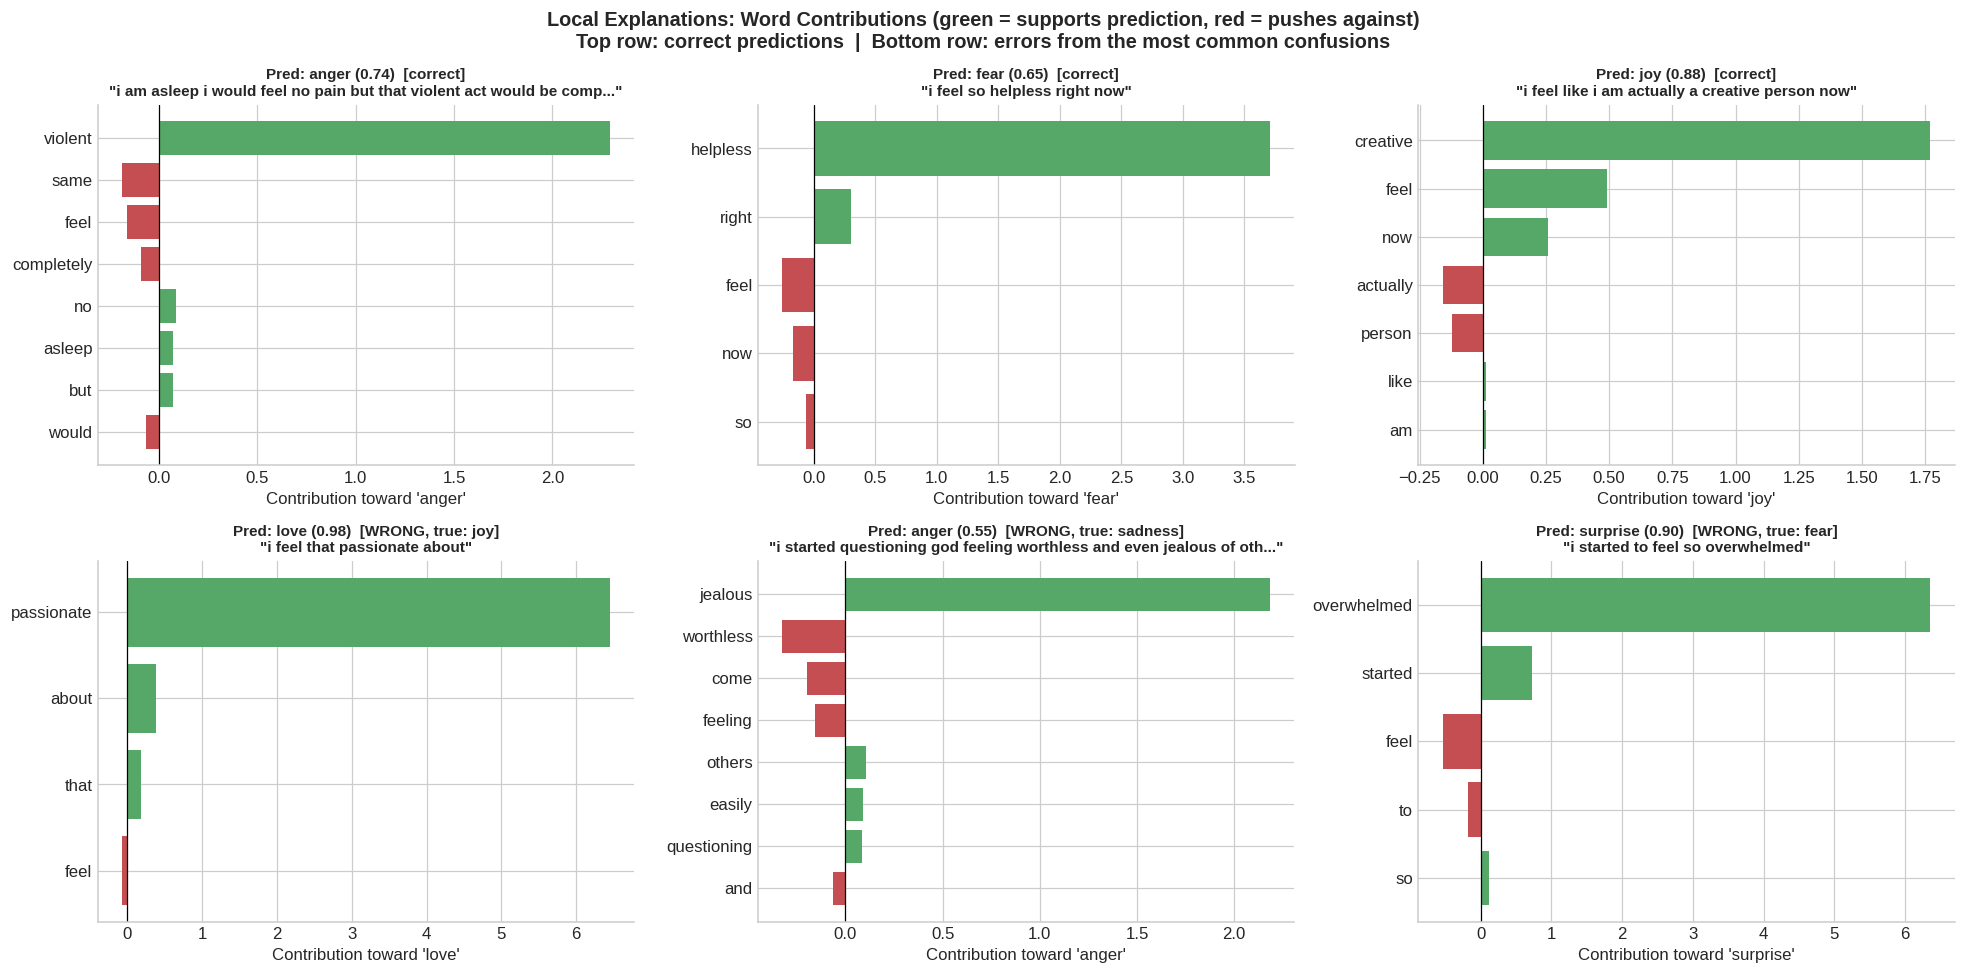

In [47]:
def explain_text(text, top_n=8):
    # Return prediction, class probabilities and per-word contributions for one text.
    proc = preprocess_text(text)
    x = vec.transform([proc])
    probs = pd.Series(clf.predict_proba(x)[0], index=CLF_CLASSES)
    pred = probs.idxmax()
    nz = x.nonzero()[1]
    contrib = pd.DataFrame({"feature": FEATURES[nz], "tfidf": x.toarray()[0, nz],
                            "contribution": x.toarray()[0, nz] * COEF_C[CLF_CLASSES.index(pred), nz]})
    contrib = contrib.reindex(contrib["contribution"].abs().sort_values(ascending=False).index).head(top_n)
    return pred, probs, contrib.reset_index(drop=True)

def plot_explanation(text, true_label=None, ax=None, top_n=8):
    pred, probs, contrib = explain_text(text, top_n)
    c = contrib.iloc[::-1]
    ax.barh(c["feature"], c["contribution"], color=["#55A868" if v > 0 else "#C44E52" for v in c["contribution"]])
    ax.axvline(0, color="black", lw=0.8)
    short = text if len(text) <= 70 else text[:67] + "..."
    status = "" if true_label is None else ("  [correct]" if true_label == pred else f"  [WRONG, true: {true_label}]")
    ax.set_title(f"Pred: {pred} ({probs[pred]:.2f}){status}\n\"{short}\"", fontsize=10)
    ax.set_xlabel(f"Contribution toward '{pred}'")

correct_ex = test_df[test_df["correct"]].groupby("emotion").sample(1, random_state=SEED).head(3)
wrong_ex = pd.concat([errors[(errors["emotion"] == r.true) & (errors["predicted"] == r.predicted)].sample(1, random_state=SEED)
                      for r in TOP_CONFUSIONS.itertuples()])
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (_, r) in zip(axes[0], correct_ex.iterrows()):
    plot_explanation(r["text"], r["emotion"], ax)
for ax, (_, r) in zip(axes[1], wrong_ex.iterrows()):
    plot_explanation(r["text"], r["emotion"], ax)
plt.suptitle("Local Explanations: Word Contributions (green = supports prediction, red = pushes against)\n"
             "Top row: correct predictions  |  Bottom row: errors from the most common confusions",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

**Interpretation (local):**
- **Correct predictions:** the prediction is usually driven by **one or two strong emotion words** (green bars), while the other words contribute little.
- **Errors:** the explanations show *why* the model was misled. The text contains a word strongly linked to the **predicted** emotion, and that word outweighs the context that a human would use to reach the true label.

Explanation format demonstrated: **Input text → Predicted emotion (+ confidence) → Important words (contributions).**

### 14.1 Explainability sanity check: how much does the model depend on single keywords? (occlusion test)

**Auto-summary:** Removing just the single most influential word changes the prediction for **58.8%** of correctly classified test texts (1,774 texts tested).

,% of predictions that flip
emotion,
sadness,53.3
joy,31.1
love,91.7
anger,87.6
fear,89.6
surprise,96.3


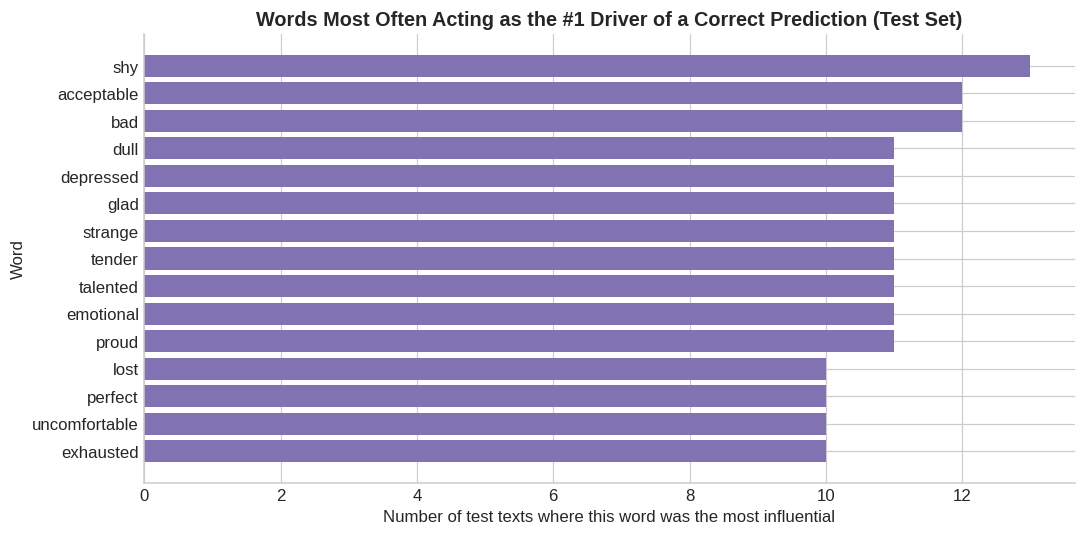

**Most frequent #1 driver word per predicted emotion:** *sadness* ← 'bad', *joy* ← 'acceptable', *love* ← 'tender', *anger* ← 'bothered', *fear* ← 'shy', *surprise* ← 'curious'. Across all correct predictions, **365** different words acted as the #1 driver.

KEY EXPLAINABILITY FINDING: Correct predictions are usually driven by a single feeling-adjective (e.g. 'bad'→sadness, 'acceptable'→joy, 'tender'→love, 'bothered'→anger); removing that one word flips 58.8% of correct predictions, so the model depends heavily on single keywords.


In [48]:
def top_unigram(proc_text, cls):
    x = vec.transform([proc_text]); nz = x.nonzero()[1]
    if len(nz) == 0:
        return None
    contrib = x.toarray()[0, nz] * COEF_C[CLF_CLASSES.index(cls), nz]
    feats = FEATURES[nz]
    uni = [(f, c) for f, c in zip(feats, contrib) if " " not in f]
    return max(uni, key=lambda t: t[1])[0] if uni else None

correct_df = test_df[test_df["correct"]].copy()
correct_df["top_word"] = [top_unigram(t, p) for t, p in zip(correct_df["processed_text"], correct_df["predicted"])]
correct_df["occluded_text"] = [" ".join(w for w in t.split() if w != tw) for t, tw in zip(correct_df["processed_text"], correct_df["top_word"])]
correct_df["pred_after_occlusion"] = final_model.predict(correct_df["occluded_text"])
OCCLUSION_FLIP_RATE = (correct_df["pred_after_occlusion"] != correct_df["predicted"]).mean()

flip_by_class = correct_df.assign(flip=correct_df["pred_after_occlusion"] != correct_df["predicted"]).groupby("emotion")["flip"].mean().reindex(LABEL_NAMES)
display(Markdown(f"**Auto-summary:** Removing just the single most influential word changes the prediction for "
                 f"**{OCCLUSION_FLIP_RATE*100:.1f}%** of correctly classified test texts ({len(correct_df):,} texts tested)."))
display(flip_by_class.mul(100).round(1).rename("% of predictions that flip").to_frame())

top_word_freq = correct_df["top_word"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top_word_freq.index[::-1], top_word_freq.values[::-1], color="#8172B3")
ax.set_title("Words Most Often Acting as the #1 Driver of a Correct Prediction (Test Set)")
ax.set_xlabel("Number of test texts where this word was the most influential"); ax.set_ylabel("Word")
plt.tight_layout(); plt.show()
DISTINCT_DRIVERS = correct_df["top_word"].nunique()
driver_per_emotion = {e: correct_df.loc[correct_df["predicted"] == e, "top_word"].value_counts().index[0] for e in LABEL_NAMES}
display(Markdown("**Most frequent #1 driver word per predicted emotion:** " +
                 ", ".join(f"*{e}* ← '{w}'" for e, w in driver_per_emotion.items()) +
                 f". Across all correct predictions, **{DISTINCT_DRIVERS}** different words acted as the #1 driver."))
KEY_XAI_FINDING = (f"Correct predictions are usually driven by a single feeling-adjective (e.g. " +
                   ", ".join(f"'{w}'→{e}" for e, w in list(driver_per_emotion.items())[:4]) +
                   f"); removing that one word flips {OCCLUSION_FLIP_RATE*100:.1f}% of correct predictions, so the model depends heavily on single keywords.")
print("KEY EXPLAINABILITY FINDING:", KEY_XAI_FINDING)

**Interpretation:** A large share of correct predictions depends on **a single word**, and the driver words are spread over many different feeling-adjectives rather than a few generic ones. The model is accurate largely because this dataset's texts usually contain an explicit emotion word. When that word is missing, negated or used ironically, the model has little else to rely on. This links the explainability result directly to the audit (negation) and to the limitations.

**Limitations of this explainability method:**
- Contributions show **what the model uses**, not **how a human understands** emotion. They do not "prove" the model reasons correctly.
- Because features are individual words, the explanation cannot show interactions such as *"not" + "happy"*.
- The occlusion test removes a word and creates slightly unnatural sentences. It measures dependence, not correctness.
- Weights of correlated words (e.g. *scared* / *afraid*) can share credit in ways that are hard to interpret individually.



# 15. Model Limitations

We separate **observed limitations**, which are backed by evidence produced in this notebook, from **potential limitations**, which are reasonable concerns we did not directly measure.

### 15.1 Controlled negation test (observed)
We give the model pairs of hand-written sentences: an emotional statement and its **negated** version. A model that understands negation should **not** keep predicting the negated emotion. *(This is a small, illustrative probe of 6 pairs, not a statistical test. It complements the audit in Section 13.2.)*

In [49]:
NEGATION_PROBES = [
    ("i feel happy today",               "i do not feel happy today",               "joy"),
    ("i feel so sad about this",         "i do not feel sad about this",            "sadness"),
    ("i am scared of the dark",          "i am not scared of the dark anymore",     "fear"),
    ("i feel angry at my brother",       "i am not angry at my brother",            "anger"),
    ("i feel so loved by my friends",    "i do not feel loved by my friends",       "love"),
    ("i was surprised by the result",    "i was not surprised by the result",       "surprise"),
]
probe_rows = []
for pos, neg, emo in NEGATION_PROBES:
    p_pos, pr_pos, _ = explain_text(pos); p_neg, pr_neg, _ = explain_text(neg)
    probe_rows.append({"negated emotion": emo, "original sentence": pos, "pred (original)": p_pos,
                       f"P(emotion) original": round(pr_pos[emo], 3),
                       "negated sentence": neg, "pred (negated)": p_neg, "P(emotion) negated": round(pr_neg[emo], 3),
                       "still predicts negated emotion?": p_neg == emo})
probe_df = pd.DataFrame(probe_rows)
display(probe_df)
NEG_PROBE_FAILS = int(probe_df["still predicts negated emotion?"].sum())
display(Markdown(f"**Auto-summary:** In **{NEG_PROBE_FAILS} of {len(probe_df)}** negated sentences the model still predicts "
                 f"the emotion that is being negated."))

,negated emotion,original sentence,pred (original),P(emotion) original,negated sentence,pred (negated),P(emotion) negated,still predicts negated emotion?
0,joy,i feel happy today,joy,0.930,i do not feel happy today,joy,0.861,True
1,sadness,i feel so sad about this,sadness,0.843,i do not feel sad about this,sadness,0.776,True
2,fear,i am scared of the dark,fear,0.996,i am not scared of the dark anymore,fear,0.984,True
3,anger,i feel angry at my brother,anger,0.941,i am not angry at my brother,anger,0.944,True
4,love,i feel so loved by my friends,love,0.935,i do not feel loved by my friends,love,0.913,True
5,surprise,i was surprised by the result,surprise,0.997,i was not surprised by the result,surprise,0.995,True


**Auto-summary:** In **6 of 6** negated sentences the model still predicts the emotion that is being negated.

### 15.2 Illustrative sarcasm probe (potential limitation, no labelled sarcasm data available)

In [50]:
SARCASM_PROBES = ["oh great another monday i just love waiting in traffic for two hours",
                  "wonderful my phone died right before my interview what a perfect day"]
for s in SARCASM_PROBES:
    p, pr, c = explain_text(s)
    print(f"'{s}'\n   → predicted: {p} ({pr[p]:.2f});  top words: {', '.join(c.loc[c['contribution'] > 0, 'feature'].head(3))}\n")

'oh great another monday i just love waiting in traffic for two hours'
   → predicted: joy (0.36);  top words: two, love, oh

'wonderful my phone died right before my interview what a perfect day'
   → predicted: joy (0.83);  top words: wonderful, perfect, day



### 15.3 Evidence-based limitation summary (auto-generated)

In [51]:
LIMITATIONS_OBSERVED = [
    ("Negation is not understood",
     f"Controlled probe: {NEG_PROBE_FAILS}/{len(probe_df)} negated sentences still predicted as the negated emotion, with high probability (15.1). "
     f"Audit 2 gap {NEG_DIFF:+.3f} overall, but " + ("mostly explained by text length (13.4)." if NEG_CONFOUNDED else "persisting within length groups (13.4).")),
    ("Lower performance on longer texts",
     f"Audit 1: macro-F1 short = {s_f1:.3f} vs long = {l_f1:.3f}; performance decreases across length bands (13.5)."),
    ("Heavy reliance on single keywords",
     f"Occlusion test: removing one word flips {OCCLUSION_FLIP_RATE*100:.1f}% of correct predictions (14.1)."),
    ("Weak on rare / overlapping emotions",
     f"Weakest class '{worst_cls}' (F1 = {per_class.loc[worst_cls,'f1-score']:.3f}); most common confusion {TOP_CONFUSIONS.loc[0,'true']} → {TOP_CONFUSIONS.loc[0,'predicted']} ({TOP_CONFUSIONS.loc[0,'count']} texts) (Section 11)."),
    ("Label noise in the dataset",
     f"{TRAIN_CONFLICTS} training texts had conflicting labels, and {TRAIN_TEST_DIFF} of {TRAIN_TEST_SHARED} texts shared by train and test carry a different label (Section 5), which caps achievable accuracy."),
]
LIMITATIONS_POTENTIAL = [
    ("Sarcasm / irony", "Bag-of-words cannot detect irony; see the illustrative probe in 15.2. Not measured, because there is no labelled sarcasm data."),
    ("Domain / style shift", f"{FEEL_SHARE:.1f}% of texts contain a form of 'feel': the model is tuned to explicit 'i feel …' statements and may not transfer to reviews, news, formal or code-mixed text."),
    ("English-only, no emoji", "Trained only on lower-cased English without emoji or punctuation, so signals like '!!!' or 😊 are ignored."),
    ("Single-label output", "Real texts can express several emotions at once; the model must choose one."),
    ("No demographic information", "The dataset has no author attributes, so fairness across groups of *people* could not be audited."),
]
display(Markdown("#### ✅ Observed limitations (supported by evidence in this notebook)\n| Limitation | Evidence |\n|---|---|\n" +
                 "\n".join(f"| **{a}** | {b} |" for a, b in LIMITATIONS_OBSERVED)))
display(Markdown("#### ⚠️ Potential limitations (plausible, not directly measured)\n| Limitation | Reason |\n|---|---|\n" +
                 "\n".join(f"| **{a}** | {b} |" for a, b in LIMITATIONS_POTENTIAL)))

# The main limitation is negation if the direct (controlled) test fails for at least half the pairs; otherwise length.
MAIN_LIMITATION = LIMITATIONS_OBSERVED[0] if NEG_PROBE_FAILS >= len(probe_df) / 2 else LIMITATIONS_OBSERVED[1]
print("MAIN (honest) LIMITATION FOR THE PITCH:", MAIN_LIMITATION[0], "—", MAIN_LIMITATION[1])

#### ✅ Observed limitations (supported by evidence in this notebook)
| Limitation | Evidence |
|---|---|
| **Negation is not understood** | Controlled probe: 6/6 negated sentences still predicted as the negated emotion, with high probability (15.1). Audit 2 gap -0.057 overall, but mostly explained by text length (13.4). |
| **Lower performance on longer texts** | Audit 1: macro-F1 short = 0.887 vs long = 0.801; performance decreases across length bands (13.5). |
| **Heavy reliance on single keywords** | Occlusion test: removing one word flips 58.8% of correct predictions (14.1). |
| **Weak on rare / overlapping emotions** | Weakest class 'surprise' (F1 = 0.701); most common confusion joy → love (55 texts) (Section 11). |
| **Label noise in the dataset** | 30 training texts had conflicting labels, and 11 of 11 texts shared by train and test carry a different label (Section 5), which caps achievable accuracy. |

#### ⚠️ Potential limitations (plausible, not directly measured)
| Limitation | Reason |
|---|---|
| **Sarcasm / irony** | Bag-of-words cannot detect irony; see the illustrative probe in 15.2. Not measured, because there is no labelled sarcasm data. |
| **Domain / style shift** | 98.8% of texts contain a form of 'feel': the model is tuned to explicit 'i feel …' statements and may not transfer to reviews, news, formal or code-mixed text. |
| **English-only, no emoji** | Trained only on lower-cased English without emoji or punctuation, so signals like '!!!' or 😊 are ignored. |
| **Single-label output** | Real texts can express several emotions at once; the model must choose one. |
| **No demographic information** | The dataset has no author attributes, so fairness across groups of *people* could not be audited. |

MAIN (honest) LIMITATION FOR THE PITCH: Negation is not understood — Controlled probe: 6/6 negated sentences still predicted as the negated emotion, with high probability (15.1). Audit 2 gap -0.057 overall, but mostly explained by text length (13.4).


# 16. New Text Prediction Demo

`predict_emotion()` takes **any new sentence**, applies the **same preprocessing** as training, and returns the predicted emotion, the confidence, the full probability distribution and the words that drove the prediction.

*Note: these demo sentences are new and unlabelled. The predictions are simply what the model outputs, and they are not guaranteed to be "correct".*

In [52]:
def predict_emotion(text, show=True, top_words=3):
    pred, probs, contrib = explain_text(text)
    drivers = contrib.loc[contrib["contribution"] > 0, "feature"].head(top_words).tolist()
    if show:
        print(f"Input            : {text}")
        print(f"Predicted Emotion: {pred.upper()}   (confidence {probs[pred]:.1%})")
        for emo, p in probs.sort_values(ascending=False).items():
            print(f"   {emo:<9} {'█' * int(round(p * 40)):<40} {p:.1%}")
        print(f"Key words        : {', '.join(drivers) if drivers else '(none: no known words)'}\n")
    return {"text": text, "predicted_emotion": pred, "confidence": round(float(probs[pred]), 4), "key_words": drivers}

DEMO_SENTENCES = [
    "I got selected for my dream job!",
    "I feel so lonely since my best friend moved away.",
    "I am furious that they cancelled my flight without telling me.",
    "I feel nervous and worried about my exam results tomorrow.",
    "I feel so loved and cared for by my family.",
    "I was amazed when I saw how much the city had changed.",
]
demo_results = [predict_emotion(s) for s in DEMO_SENTENCES]

Input            : I got selected for my dream job!
Predicted Emotion: JOY   (confidence 36.0%)
   joy       ██████████████                           36.0%
   anger     ███████                                  17.6%
   sadness   ███████                                  17.2%
   love      ██████                                   14.1%
   fear      █████                                    11.4%
   surprise  ██                                       3.8%
Key words        : got, job, selected

Input            : I feel so lonely since my best friend moved away.
Predicted Emotion: SADNESS   (confidence 77.3%)
   sadness   ███████████████████████████████          77.3%
   anger     ████                                     11.1%
   joy       ██                                       5.3%
   fear      ██                                       4.3%
   love      █                                        1.6%
   surprise                                           0.5%
Key words        : lonely, feel, 

In [53]:
demo_df = pd.DataFrame(demo_results)[["text", "predicted_emotion", "confidence", "key_words"]]
display(demo_df)
low = demo_df[demo_df["confidence"] < 0.5]
display(Markdown(
    f"**Auto-summary:** {len(demo_df) - len(low)} of {len(demo_df)} demo sentences were predicted with confidence ≥ 50%. " +
    (("Low-confidence cases: " + "; ".join(f"*\"{r.text}\"* → {r.predicted_emotion} ({r.confidence:.0%})" for r in low.itertuples()) +
      ". These sentences express emotion through a **situation** rather than an explicit feeling word, so the model has no strong "
      "keyword to rely on. This is the same keyword dependence found in Section 14.")
     if len(low) else "All demo sentences contain explicit feeling words, which is where this model is most confident.")))

,text,predicted_emotion,confidence,key_words
0,I got selected for my dream job!,joy,0.3599,"[got, job, selected]"
1,I feel so lonely since my best friend moved away.,sadness,0.7726,"[lonely, feel, moved]"
2,I am furious that they cancelled my flight without telling me.,anger,0.8722,"[furious, telling, without]"
3,I feel nervous and worried about my exam results tomorrow.,fear,0.9722,"[nervous, exam, worried]"
4,I feel so loved and cared for by my family.,love,0.9310,"[loved, cared, for]"
5,I was amazed when I saw how much the city had changed.,surprise,0.9661,"[amazed, much, how]"


**Auto-summary:** 5 of 6 demo sentences were predicted with confidence ≥ 50%. Low-confidence cases: *"I got selected for my dream job!"* → joy (36%). These sentences express emotion through a **situation** rather than an explicit feeling word, so the model has no strong keyword to rely on. This is the same keyword dependence found in Section 14.

### 🎤 Try your own sentence (edit the text and re-run this cell during the presentation)

In [54]:
your_text = "I feel sad"
_ = predict_emotion(your_text)

Input            : I feel sad
Predicted Emotion: SADNESS   (confidence 94.5%)
   sadness   ██████████████████████████████████████   94.5%
   joy       █                                        2.7%
   anger     █                                        1.3%
   fear                                               1.0%
   love                                               0.3%
   surprise                                           0.2%
Key words        : sad, feel

